# Simple Multimodal Seizure Detection Notebook

This notebook builds a clean end-to-end seizure detection pipeline from:

- `ds005873/sub-001` and `sub-002` for EEG, ECG, EMG, and movement
- `ds007313/derivatives/denoising/.../sub-A006_task-rest_bold_stc_brain_moco_BP_nostd_inT1w_inTemplate.nii.gz` for post-hoc fMRI interpretation

The notebook keeps everything in one place:

1. BIDS loading and annotation parsing
2. Window extraction into seizure and background samples
3. Early exploratory data visualization and multimodal signal inspection
4. Train/validation/test split and normalization
5. A baseline multi-branch CNN
6. An improved attention-fusion CNN family
7. Training, evaluation, comparison plots, and wearable-signal XAI
8. Post-hoc fMRI XAI summary and a final interpretation block


## Notes and assumptions

- The physiology data requested as `sub-01` and `sub-02` are interpreted here as `sub-001` and `sub-002`, because that is how the dataset is named on disk.
- EEG/ECG/EMG are sampled at 256 Hz. Movement files contain 12 channels, so this notebook keeps only one 3-axis accelerometer triplet to match the requested `(3, time)` shape.
- The movement triplet used by default is `EEG SD ACC X/Y/Z`. You can switch to the chest accelerometer by changing `MOV_SENSOR_PREFIX`.
- Seizure-centered intervals are extracted with `±120 s` padding, but each 10-second window is labeled positive only if it overlaps an actual seizure annotation.
- `impd` intervals are excluded.
- The fMRI add-on is descriptive XAI over a separate denoised derivative: hotspot maps, temporal-variability maps, and voxel ranking tables support interpretation, but the seizure classifier is never trained on fMRI.
- The fMRI file comes from a different dataset (`ds007313`, subject `sub-A006`) than the seizure physiology data (`ds005873`, subjects `sub-001` and `sub-002`). The final interpretation is therefore post-hoc and illustrative, not subject-matched validation.


In [2]:
import copy
import json
import math
import os
import random
import re
from collections import OrderedDict
from itertools import product
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import mne
import nibabel as nib
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from nilearn import image, plotting
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

sns.set_theme(style="whitegrid")
mne.set_log_level("ERROR")

DATA_ROOT = Path("ds005873")
FMRI_PATH = Path(
    "ds007313/derivatives/denoising/slice_wise/2_func_in_template/brain/"
    "sub-A006_task-rest_bold_stc_brain_moco_BP_nostd_inT1w_inTemplate.nii.gz"
)

SUBJECTS = ["sub-001", "sub-002"]
SESSION = "ses-01"
WINDOW_SEC = 10
WINDOW_STRIDE_SEC = 10
SEIZURE_PADDING_SEC = 120
MOV_SENSOR_PREFIX = "EEG SD ACC"
BACKGROUND_RATIO = 1.0
TEST_SIZE = 0.25
VAL_SIZE = 0.20
RANDOM_SEED = 7

BATCH_SIZE = 32
PRETRAIN_BATCH_SIZE = 64
EPOCHS = 20
PRETRAIN_EPOCHS = 4
LEARNING_RATE = 1e-3
PRETRAIN_LR = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT = 0.35
FREEZE_FIRST_BLOCK = False
EARLY_STOPPING_PATIENCE = 4
EARLY_STOPPING_MIN_DELTA = 1e-3
USE_PRETRAINED_ENCODERS = True
INTEGRATED_GRADIENT_STEPS = 24

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")


Using device: cuda


In [3]:
# Seed Python, NumPy, and PyTorch RNGs for reproducible runs.
def set_seed(seed: int = 7):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)

# Load a UTF-8 JSON file and return its parsed contents.
def read_json(path: Path):
    with open(path, "r", encoding="utf-8") as handle:
        return json.load(handle)

# Extract the BIDS run identifier from a file name.
def parse_run_id(path: Path) -> str:
    match = re.search(r"run-(\d+)", path.name)
    if match is None:
        raise ValueError(f"Could not parse run id from {path.name}")
    return match.group(1)

# Build a table of runs that have all required modality files.
def build_run_table(data_root: Path, subjects):
    run_rows = []
    for subject in subjects:
        eeg_dir = data_root / subject / SESSION / "eeg"
        for event_path in sorted(eeg_dir.glob("*_events.tsv")):
            run_id = parse_run_id(event_path)
            stem = f"{subject}_{SESSION}_task-szMonitoring_run-{run_id}"

            paths = {
                "subject": subject,
                "run": run_id,
                "events": event_path,
                "eeg": eeg_dir / f"{stem}_eeg.edf",
                "eeg_json": eeg_dir / f"{stem}_eeg.json",
                "ecg": data_root / subject / SESSION / "ecg" / f"{stem}_ecg.edf",
                "ecg_json": data_root / subject / SESSION / "ecg" / f"{stem}_ecg.json",
                "emg": data_root / subject / SESSION / "emg" / f"{stem}_emg.edf",
                "emg_json": data_root / subject / SESSION / "emg" / f"{stem}_emg.json",
                "mov": data_root / subject / SESSION / "mov" / f"{stem}_mov.edf",
                "mov_json": data_root / subject / SESSION / "mov" / f"{stem}_mov.json",
            }

            if all(Path(paths[key]).exists() for key in ["eeg", "ecg", "emg", "mov"]):
                run_rows.append(paths)
    return pd.DataFrame(run_rows)

runs_df = build_run_table(DATA_ROOT, SUBJECTS)
print(f"Number of runs found: {len(runs_df)}")
runs_df[["subject", "run"]].head()


Number of runs found: 21


,subject,run
0,sub-001,01
1,sub-001,02
2,sub-001,03
3,sub-001,04
4,sub-001,05


In [4]:
# Load event annotations and add an end timestamp for each event.
def load_events(events_path: Path) -> pd.DataFrame:
    events = pd.read_csv(events_path, sep="\t")
    events["end"] = events["onset"] + events["duration"]
    return events

# Merge overlapping or touching time intervals into a clean list.
def merge_intervals(intervals):
    cleaned = [(float(start), float(end)) for start, end in intervals if end > start]
    if not cleaned:
        return []
    cleaned.sort(key=lambda pair: pair[0])
    merged = [list(cleaned[0])]
    for start, end in cleaned[1:]:
        if start <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], end)
        else:
            merged.append([start, end])
    return [tuple(pair) for pair in merged]

# Return the gaps not covered by the provided intervals.
def complement_intervals(intervals, start_time, end_time):
    intervals = merge_intervals(intervals)
    complement = []
    cursor = start_time
    for interval_start, interval_end in intervals:
        if interval_start > cursor:
            complement.append((cursor, interval_start))
        cursor = max(cursor, interval_end)
    if cursor < end_time:
        complement.append((cursor, end_time))
    return complement

# Compute the overlap duration between two time intervals.
def interval_overlap(a, b):
    return max(0.0, min(a[1], b[1]) - max(a[0], b[0]))

# Find the seizure event with the largest overlap with a window.
def best_overlapping_event(window_interval, seizure_events: pd.DataFrame):
    if seizure_events.empty:
        return None
    overlaps = seizure_events.apply(
        lambda row: interval_overlap(window_interval, (row["onset"], row["end"])),
        axis=1,
    )
    if overlaps.max() <= 0:
        return None
    return seizure_events.iloc[int(overlaps.values.argmax())]

# Create labeled seizure-context and background window specifications.
def build_window_specs(events: pd.DataFrame, duration_sec: float):
    seizure_events = events[events["eventType"].astype(str).str.startswith("sz")].copy()
    impd_events = events[events["eventType"] == "impd"].copy()

    seizure_intervals = list(zip(seizure_events["onset"], seizure_events["end"]))
    impd_intervals = list(zip(impd_events["onset"], impd_events["end"]))

    padded_intervals = [
        (max(0.0, start - SEIZURE_PADDING_SEC), min(duration_sec, end + SEIZURE_PADDING_SEC))
        for start, end in seizure_intervals
    ]
    context_intervals = merge_intervals(padded_intervals)

    exclusion_intervals = merge_intervals(padded_intervals + impd_intervals)
    background_intervals = complement_intervals(exclusion_intervals, 0.0, duration_sec)

    context_specs = []
    for interval_start, interval_end in context_intervals:
        current = interval_start
        while current + WINDOW_SEC <= interval_end + 1e-9:
            window = (current, current + WINDOW_SEC)

            if any(interval_overlap(window, artifact) > 0 for artifact in impd_intervals):
                current += WINDOW_STRIDE_SEC
                continue

            matched = best_overlapping_event(window, seizure_events)
            label = int(matched is not None)
            context_specs.append(
                {
                    "start": current,
                    "end": current + WINDOW_SEC,
                    "label": label,
                    "source": "seizure_context",
                    "event_type": matched["eventType"] if matched is not None else "context_background",
                    "lateralization": matched["lateralization"] if matched is not None else "n/a",
                    "localization": matched["localization"] if matched is not None else "n/a",
                }
            )
            current += WINDOW_STRIDE_SEC

    background_specs = []
    for interval_start, interval_end in background_intervals:
        current = interval_start
        while current + WINDOW_SEC <= interval_end + 1e-9:
            background_specs.append(
                {
                    "start": current,
                    "end": current + WINDOW_SEC,
                    "label": 0,
                    "source": "background",
                    "event_type": "bckg",
                    "lateralization": "n/a",
                    "localization": "n/a",
                }
            )
            current += WINDOW_STRIDE_SEC

    return context_specs, background_specs, seizure_events


In [5]:
# Open the EEG, ECG, EMG, and movement EDF recordings for one run.
def open_multimodal_recordings(run_row):
    return {
        "eeg": mne.io.read_raw_edf(run_row["eeg"], preload=False, verbose="ERROR"),
        "ecg": mne.io.read_raw_edf(run_row["ecg"], preload=False, verbose="ERROR"),
        "emg": mne.io.read_raw_edf(run_row["emg"], preload=False, verbose="ERROR"),
        "mov": mne.io.read_raw_edf(run_row["mov"], preload=False, verbose="ERROR"),
    }

# Close any open raw recording objects for a run.
def close_recordings(raws):
    for raw in raws.values():
        close_fn = getattr(raw, "close", None)
        if callable(close_fn):
            close_fn()

# Choose the 3-axis movement channels used for accelerometer windows.
def pick_mov_channels(raw):
    preferred = [name for name in raw.ch_names if name.startswith(MOV_SENSOR_PREFIX)]
    if len(preferred) == 3:
        return preferred
    acc_channels = [name for name in raw.ch_names if "ACC" in name]
    if len(acc_channels) >= 3:
        return acc_channels[:3]
    raise ValueError(f"Could not find 3 accelerometer channels in {raw.ch_names}")

# Convert a window duration into the expected sample count.
def get_expected_samples(sfreq: float, window_sec: float) -> int:
    return int(round(sfreq * window_sec))

# Extract one fixed-length time window and pad or trim it as needed.
def extract_window(raw, start_sec, window_sec, picks=None):
    sfreq = float(raw.info["sfreq"])
    start_sample = int(round(start_sec * sfreq))
    stop_sample = int(round((start_sec + window_sec) * sfreq))
    data = raw.get_data(picks=picks, start=start_sample, stop=stop_sample)
    expected_samples = get_expected_samples(sfreq, window_sec)

    if data.shape[1] < expected_samples:
        pad_width = expected_samples - data.shape[1]
        data = np.pad(data, ((0, 0), (0, pad_width)), mode="edge")
    elif data.shape[1] > expected_samples:
        data = data[:, :expected_samples]
    return data.astype(np.float32)

# Materialize multimodal window arrays, labels, and metadata from all runs.
def build_dataset_from_runs(runs_df: pd.DataFrame):
    all_context_specs = []
    all_background_specs = []

    for _, run_row in runs_df.iterrows():
        events = load_events(run_row["events"])
        duration_sec = float(events["recordingDuration"].iloc[0])
        context_specs, background_specs, _ = build_window_specs(events, duration_sec)
        for spec in context_specs:
            spec.update({"subject": run_row["subject"], "run": run_row["run"], "run_row": run_row})
        for spec in background_specs:
            spec.update({"subject": run_row["subject"], "run": run_row["run"], "run_row": run_row})
        all_context_specs.extend(context_specs)
        all_background_specs.extend(background_specs)

    positive_context_count = sum(spec["label"] for spec in all_context_specs)
    if positive_context_count == 0:
        raise RuntimeError("No seizure windows were found.")

    rng = np.random.default_rng(RANDOM_SEED)
    max_background = min(len(all_background_specs), int(positive_context_count * BACKGROUND_RATIO))
    if len(all_background_specs) > max_background:
        selected_indices = rng.choice(len(all_background_specs), size=max_background, replace=False)
        selected_background_specs = [all_background_specs[int(idx)] for idx in selected_indices]
    else:
        selected_background_specs = all_background_specs

    selected_specs = sorted(
        all_context_specs + selected_background_specs,
        key=lambda item: (item["subject"], item["run"], item["start"]),
    )

    modality_arrays = {"eeg": [], "ecg": [], "emg": [], "mov": []}
    metadata_rows = []

    specs_by_run = {}
    for spec in selected_specs:
        specs_by_run.setdefault((spec["subject"], spec["run"]), []).append(spec)

    for (_, _), run_specs in specs_by_run.items():
        run_row = run_specs[0]["run_row"]
        raws = open_multimodal_recordings(run_row)
        mov_picks = pick_mov_channels(raws["mov"])
        eeg_channels = list(raws["eeg"].ch_names)

        for spec in run_specs:
            start_sec = spec["start"]

            modality_arrays["eeg"].append(extract_window(raws["eeg"], start_sec, WINDOW_SEC))
            modality_arrays["ecg"].append(extract_window(raws["ecg"], start_sec, WINDOW_SEC))
            modality_arrays["emg"].append(extract_window(raws["emg"], start_sec, WINDOW_SEC))
            modality_arrays["mov"].append(extract_window(raws["mov"], start_sec, WINDOW_SEC, picks=mov_picks))

            metadata_rows.append(
                {
                    "subject": spec["subject"],
                    "run": spec["run"],
                    "window_start_sec": spec["start"],
                    "window_end_sec": spec["end"],
                    "label": spec["label"],
                    "source": spec["source"],
                    "event_type": spec["event_type"],
                    "lateralization": spec["lateralization"],
                    "localization": spec["localization"],
                    "eeg_channels": eeg_channels,
                    "mov_channels": mov_picks,
                }
            )
        close_recordings(raws)

    arrays = {name: np.stack(values).astype(np.float32) for name, values in modality_arrays.items()}
    metadata = pd.DataFrame(metadata_rows)
    labels = metadata["label"].to_numpy(dtype=np.float32)
    return arrays, labels, metadata

arrays, labels, metadata = build_dataset_from_runs(runs_df)

print("Window tensor shapes:")
for name, value in arrays.items():
    print(f"  {name}: {value.shape}")
print(f"Positive windows: {int(labels.sum())}")
print(f"Negative windows: {int((labels == 0).sum())}")
metadata.head()


Window tensor shapes:
  eeg: (884, 2, 2560)
  ecg: (884, 1, 2560)
  emg: (884, 1, 2560)
  mov: (884, 3, 250)
Positive windows: 223
Negative windows: 661


,subject,run,window_start_sec,window_end_sec,label,source,event_type,lateralization,localization,eeg_channels,mov_channels
0,sub-001,01,2730.0,2740.0,0,background,bckg,n/a,n/a,"[BTEleft SD, CROSStop SD]","[EEG SD ACC X, EEG SD ACC Y, EEG SD ACC Z]"
1,sub-001,01,3850.0,3860.0,0,background,bckg,n/a,n/a,"[BTEleft SD, CROSStop SD]","[EEG SD ACC X, EEG SD ACC Y, EEG SD ACC Z]"
2,sub-001,01,5560.0,5570.0,0,background,bckg,n/a,n/a,"[BTEleft SD, CROSStop SD]","[EEG SD ACC X, EEG SD ACC Y, EEG SD ACC Z]"
3,sub-001,01,8630.0,8640.0,0,background,bckg,n/a,n/a,"[BTEleft SD, CROSStop SD]","[EEG SD ACC X, EEG SD ACC Y, EEG SD ACC Z]"
4,sub-001,01,10440.0,10450.0,0,background,bckg,n/a,n/a,"[BTEleft SD, CROSStop SD]","[EEG SD ACC X, EEG SD ACC Y, EEG SD ACC Z]"


## Exploratory Data Visualization

- Inspect class balance and seizure-localization labels before modeling.
- Visualize one seizure window and one background window across EEG, ECG, EMG, and movement.


,metric,value
0,total_windows,884
1,seizure_windows,223
2,background_windows,661
3,subjects,2
4,runs,21
5,positive_localizations,3


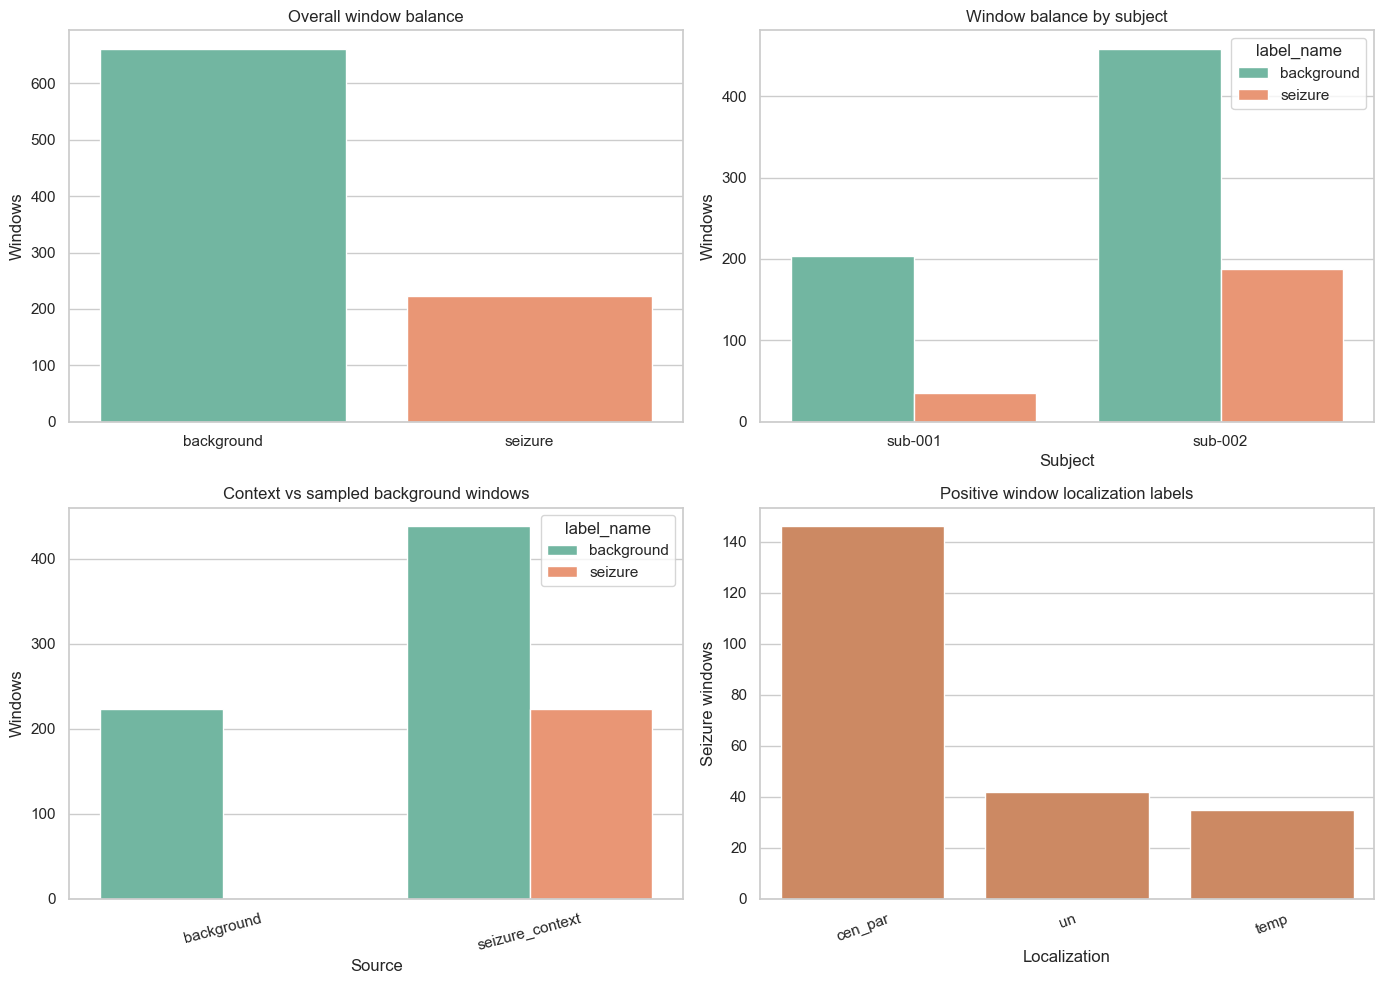

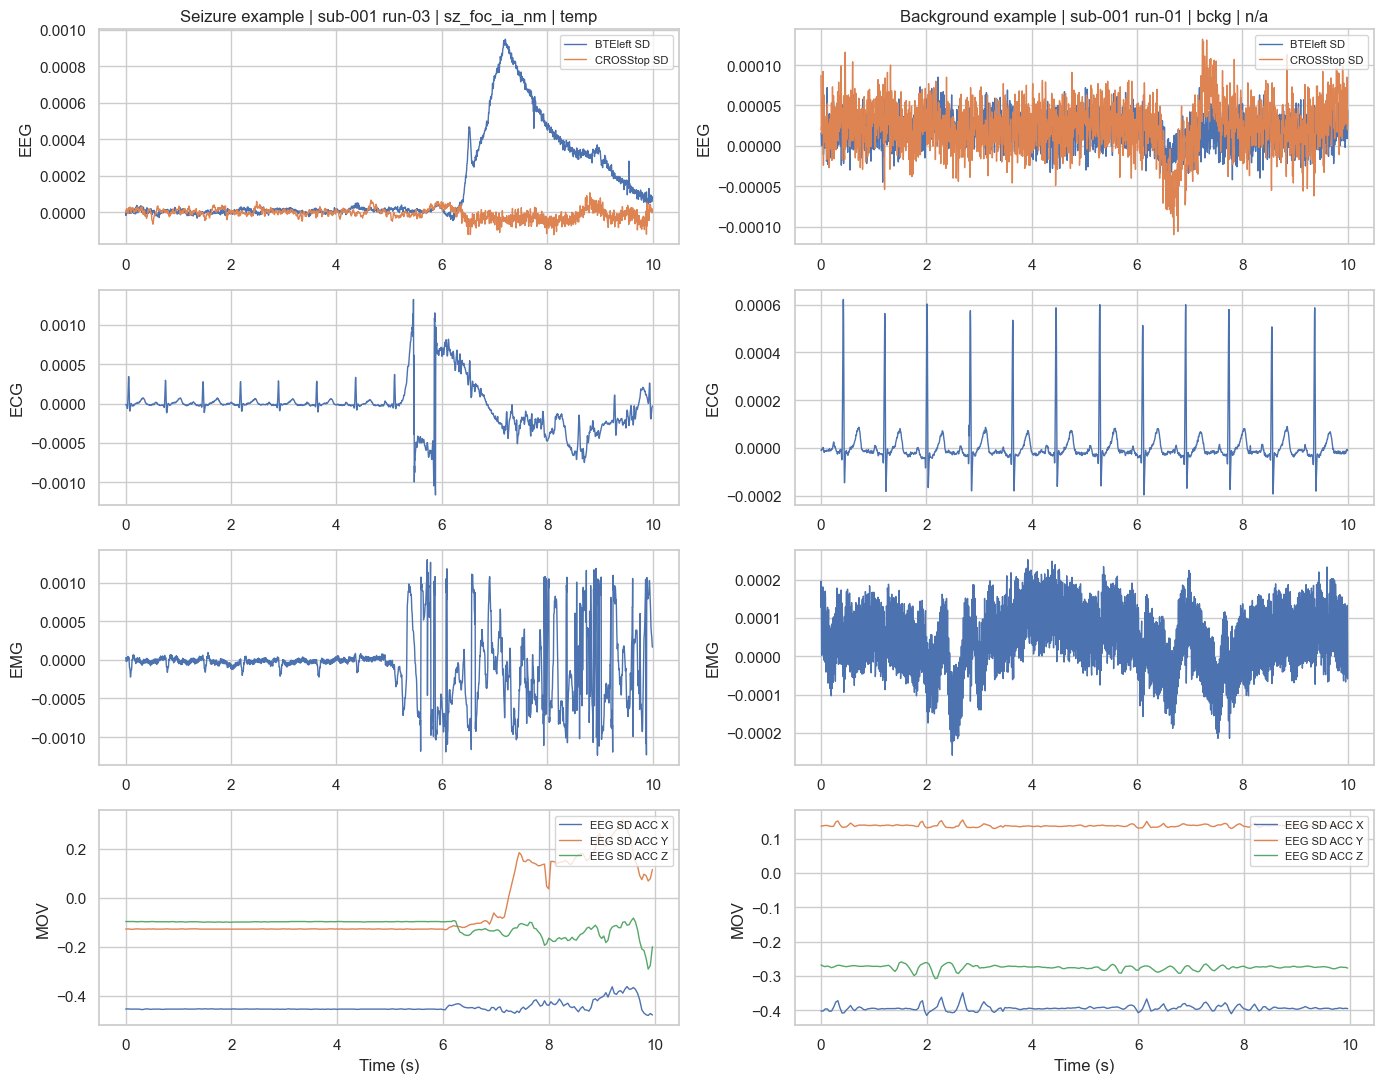

In [6]:
LABEL_NAME_MAP = {0: "background", 1: "seizure"}


# Summarize the dataset composition in a compact metrics table.
def build_window_overview(metadata: pd.DataFrame) -> pd.DataFrame:
    positive_mask = metadata["label"] == 1
    return pd.DataFrame(
        {
            "metric": [
                "total_windows",
                "seizure_windows",
                "background_windows",
                "subjects",
                "runs",
                "positive_localizations",
            ],
            "value": [
                len(metadata),
                int(positive_mask.sum()),
                int((~positive_mask).sum()),
                metadata["subject"].nunique(),
                metadata[["subject", "run"]].drop_duplicates().shape[0],
                int(metadata.loc[positive_mask, "localization"].nunique()),
            ],
        }
    )


# Visualize label balance and seizure-localization distributions.
def plot_dataset_overview(metadata: pd.DataFrame):
    viz_df = metadata.copy()
    viz_df["label_name"] = viz_df["label"].map(LABEL_NAME_MAP)
    positive_df = viz_df[viz_df["label"] == 1].copy()
    positive_df["localization_clean"] = positive_df["localization"].replace("n/a", "unspecified")

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    sns.countplot(data=viz_df, x="label_name", hue="label_name", palette="Set2", ax=axes[0, 0], legend=False)
    axes[0, 0].set_title("Overall window balance")
    axes[0, 0].set_xlabel("")
    axes[0, 0].set_ylabel("Windows")

    sns.countplot(data=viz_df, x="subject", hue="label_name", palette="Set2", ax=axes[0, 1])
    axes[0, 1].set_title("Window balance by subject")
    axes[0, 1].set_xlabel("Subject")
    axes[0, 1].set_ylabel("Windows")

    sns.countplot(data=viz_df, x="source", hue="label_name", palette="Set2", ax=axes[1, 0])
    axes[1, 0].set_title("Context vs sampled background windows")
    axes[1, 0].set_xlabel("Source")
    axes[1, 0].set_ylabel("Windows")
    axes[1, 0].tick_params(axis="x", rotation=15)

    if not positive_df.empty:
        localization_order = positive_df["localization_clean"].value_counts().index
        sns.countplot(
            data=positive_df,
            x="localization_clean",
            order=localization_order,
            color="#dd8452",
            ax=axes[1, 1],
        )
        axes[1, 1].set_title("Positive window localization labels")
        axes[1, 1].set_xlabel("Localization")
        axes[1, 1].set_ylabel("Seizure windows")
        axes[1, 1].tick_params(axis="x", rotation=20)
    else:
        axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()


# Pick one seizure window and one matched background example for plotting.
def select_example_indices(metadata: pd.DataFrame):
    positive_index = int(metadata.index[metadata["label"] == 1][0])
    positive_subject = metadata.iloc[positive_index]["subject"]
    negative_candidates = metadata[(metadata["label"] == 0) & (metadata["subject"] == positive_subject)]
    if negative_candidates.empty:
        negative_index = int(metadata.index[metadata["label"] == 0][0])
    else:
        negative_index = int(negative_candidates.index[0])
    return positive_index, negative_index


# Plot side-by-side multimodal seizure and background windows.
def plot_multimodal_examples(arrays, metadata, positive_index, negative_index):
    modality_order = ["eeg", "ecg", "emg", "mov"]
    fig, axes = plt.subplots(len(modality_order), 2, figsize=(14, 11))
    column_info = [(positive_index, "Seizure example"), (negative_index, "Background example")]

    for col, (index, title_prefix) in enumerate(column_info):
        meta_row = metadata.iloc[index]
        for row, modality in enumerate(modality_order):
            signal = arrays[modality][index]
            time_axis = np.linspace(0, WINDOW_SEC, signal.shape[-1], endpoint=False)
            ax = axes[row, col]

            for channel_idx in range(signal.shape[0]):
                label = None
                if modality == "eeg":
                    label = meta_row["eeg_channels"][channel_idx]
                elif modality == "mov":
                    label = meta_row["mov_channels"][channel_idx]
                elif signal.shape[0] > 1:
                    label = f"ch{channel_idx + 1}"
                ax.plot(time_axis, signal[channel_idx], linewidth=1.0, label=label)

            if row == 0:
                ax.set_title(
                    f"{title_prefix} | {meta_row['subject']} run-{meta_row['run']} | "
                    f"{meta_row['event_type']} | {meta_row['localization']}"
                )
            ax.set_ylabel(modality.upper())
            if row == len(modality_order) - 1:
                ax.set_xlabel("Time (s)")
            if modality in {"eeg", "mov"}:
                ax.legend(loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()


window_overview = build_window_overview(metadata)
display(window_overview)
plot_dataset_overview(metadata)
positive_example_index, negative_example_index = select_example_indices(metadata)
plot_multimodal_examples(arrays, metadata, positive_example_index, negative_example_index)


In [7]:
# Compute per-modality normalization statistics from training data.
def fit_normalization_stats(train_arrays):
    stats = {}
    for modality, values in train_arrays.items():
        mean = values.mean(axis=(0, 2), keepdims=True)
        std = values.std(axis=(0, 2), keepdims=True) + 1e-6
        stats[modality] = {"mean": mean.astype(np.float32), "std": std.astype(np.float32)}
    return stats


# Standardize each modality with the previously computed training statistics.
def apply_normalization(arrays, stats):
    normalized = {}
    for modality, values in arrays.items():
        normalized[modality] = ((values - stats[modality]["mean"]) / stats[modality]["std"]).astype(np.float32)
    return normalized


indices = np.arange(len(labels))

train_val_idx, test_idx = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=labels.astype(int),
)
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=VAL_SIZE,
    random_state=RANDOM_SEED,
    stratify=labels[train_val_idx].astype(int),
)

train_arrays = {modality: values[train_idx] for modality, values in arrays.items()}
val_arrays = {modality: values[val_idx] for modality, values in arrays.items()}
test_arrays = {modality: values[test_idx] for modality, values in arrays.items()}
train_labels = labels[train_idx]
val_labels = labels[val_idx]
test_labels = labels[test_idx]
train_meta = metadata.iloc[train_idx].reset_index(drop=True)
val_meta = metadata.iloc[val_idx].reset_index(drop=True)
test_meta = metadata.iloc[test_idx].reset_index(drop=True)

normalization_stats = fit_normalization_stats(train_arrays)
train_arrays = apply_normalization(train_arrays, normalization_stats)
val_arrays = apply_normalization(val_arrays, normalization_stats)
test_arrays = apply_normalization(test_arrays, normalization_stats)


class MultimodalWindowDataset(Dataset):
    # Store multimodal arrays and labels for indexed dataset access.
    def __init__(self, arrays, labels):
        self.arrays = arrays
        self.labels = labels.astype(np.float32)

    # Return the number of labeled windows in the dataset.
    def __len__(self):
        return len(self.labels)

    # Convert one indexed multimodal window into tensors plus its label.
    def __getitem__(self, index):
        sample = {
            modality: torch.from_numpy(values[index]).float()
            for modality, values in self.arrays.items()
        }
        label = torch.tensor(self.labels[index], dtype=torch.float32)
        return sample, label, index


train_dataset = MultimodalWindowDataset(train_arrays, train_labels)
val_dataset = MultimodalWindowDataset(val_arrays, val_labels)
test_dataset = MultimodalWindowDataset(test_arrays, test_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train/val/test class balance:")
print("Train:")
print(pd.Series(train_labels).value_counts().sort_index())
print("Validation:")
print(pd.Series(val_labels).value_counts().sort_index())
print("Test:")
print(pd.Series(test_labels).value_counts().sort_index())


Train/val/test class balance:
Train:
0.0    397
1.0    133
Name: count, dtype: int64
Validation:
0.0    99
1.0    34
Name: count, dtype: int64
Test:
0.0    165
1.0     56
Name: count, dtype: int64


## Models and Training

- Baseline fusion CNN
- Attention fusion CNN
- Deeper attention CNN
- Optional encoder pretraining
- Grid search + early stopping + XAI


In [8]:
SHALLOW_ENCODER_CONFIGS = {
    "eeg": {"in_channels": 2, "hidden_channels": (32, 64), "embedding_dim": 64, "dropout": DROPOUT, "use_third_block": False},
    "ecg": {"in_channels": 1, "hidden_channels": (16, 32), "embedding_dim": 64, "dropout": DROPOUT, "use_third_block": False},
    "emg": {"in_channels": 1, "hidden_channels": (16, 32), "embedding_dim": 64, "dropout": DROPOUT, "use_third_block": False},
    "mov": {"in_channels": 3, "hidden_channels": (16, 32), "embedding_dim": 64, "dropout": DROPOUT, "use_third_block": False},
}
DEEP_ENCODER_CONFIGS = {
    "eeg": {"in_channels": 2, "hidden_channels": (32, 64, 96), "embedding_dim": 64, "dropout": DROPOUT, "use_third_block": True},
    "ecg": {"in_channels": 1, "hidden_channels": (16, 32, 48), "embedding_dim": 64, "dropout": DROPOUT, "use_third_block": True},
    "emg": {"in_channels": 1, "hidden_channels": (16, 32, 48), "embedding_dim": 64, "dropout": DROPOUT, "use_third_block": True},
    "mov": {"in_channels": 3, "hidden_channels": (16, 32, 48), "embedding_dim": 64, "dropout": DROPOUT, "use_third_block": True},
}

# Copy encoder settings and optionally override their dropout rate.
def clone_encoder_configs(configs, dropout=None):
    cloned = {}
    for name, config in configs.items():
        new_config = dict(config)
        if dropout is not None:
            new_config["dropout"] = dropout
        cloned[name] = new_config
    return cloned

class ConvEncoder(nn.Module):
    # Build a configurable 1D convolutional encoder for one modality.
    def __init__(self, in_channels, hidden_channels=(32, 64), embedding_dim=64, dropout=0.35, use_third_block=False):
        super().__init__()
        if len(hidden_channels) < 2:
            raise ValueError("ConvEncoder requires at least two convolution blocks.")

        c1, c2 = hidden_channels[:2]
        c3 = hidden_channels[2] if len(hidden_channels) > 2 else c2
        self.use_third_block = bool(use_third_block and len(hidden_channels) > 2)
        self.hidden_channels = tuple(hidden_channels)
        self.output_channels = c3 if self.use_third_block else c2

        self.conv1 = nn.Conv1d(in_channels, c1, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(c1)
        self.drop1 = nn.Dropout(dropout)
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.conv2 = nn.Conv1d(c1, c2, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(c2)
        self.drop2 = nn.Dropout(dropout)
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        if self.use_third_block:
            self.conv3 = nn.Conv1d(c2, c3, kernel_size=3, padding=1)
            self.bn3 = nn.BatchNorm1d(c3)
            self.drop3 = nn.Dropout(dropout)
            self.pool3 = nn.MaxPool1d(kernel_size=2)
        else:
            self.conv3 = None
            self.bn3 = None
            self.drop3 = None
            self.pool3 = None

        self.last_conv = self.conv3 if self.use_third_block else self.conv2
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.project = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.output_channels, embedding_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

    # Run the convolution stack and keep feature maps for optional XAI.
    def encode_sequence(self, x):
        x = self.pool1(self.drop1(F.relu(self.bn1(self.conv1(x)))))
        features = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(self.drop2(features))
        if self.use_third_block:
            features = F.relu(self.bn3(self.conv3(x)))
            x = self.pool3(self.drop3(features))
        return x, features

    # Project an input window into an embedding and optionally return features.
    def forward(self, x, return_features=False):
        encoded_sequence, features = self.encode_sequence(x)
        embedding = self.project(self.global_pool(encoded_sequence))
        if return_features:
            return embedding, features
        return embedding

    # Freeze the first convolution block for transfer-learning experiments.
    def freeze_first_block(self):
        for layer in [self.conv1, self.bn1]:
            for parameter in layer.parameters():
                parameter.requires_grad = False

class BaseMultimodalModel(nn.Module):
    # Create one encoder per modality and optionally load pretrained weights.
    def __init__(self, encoder_configs, dropout=0.35, pretrained_bank=None):
        super().__init__()
        self.encoder_configs = clone_encoder_configs(encoder_configs, dropout=dropout)
        self.modalities = ["eeg", "ecg", "emg", "mov"]
        self.eeg_encoder = ConvEncoder(**self.encoder_configs["eeg"])
        self.ecg_encoder = ConvEncoder(**self.encoder_configs["ecg"])
        self.emg_encoder = ConvEncoder(**self.encoder_configs["emg"])
        self.mov_encoder = ConvEncoder(**self.encoder_configs["mov"])
        self.embedding_dim = self.encoder_configs["eeg"]["embedding_dim"]

        if pretrained_bank is not None:
            self.load_pretrained_bank(pretrained_bank)

    # Load pretrained encoder weights for any modalities present in the bank.
    def load_pretrained_bank(self, pretrained_bank):
        for modality in self.modalities:
            state = pretrained_bank.get(modality)
            if state is not None:
                getattr(self, f"{modality}_encoder").load_state_dict(state, strict=False)

    # Encode every modality and optionally return EEG feature maps.
    def encode_modalities(self, batch, return_eeg_features=False):
        eeg_output = self.eeg_encoder(batch["eeg"], return_features=return_eeg_features)
        if return_eeg_features:
            eeg_embedding, eeg_features = eeg_output
        else:
            eeg_embedding = eeg_output
            eeg_features = None

        embeddings = OrderedDict(
            eeg=eeg_embedding,
            ecg=self.ecg_encoder(batch["ecg"]),
            emg=self.emg_encoder(batch["emg"]),
            mov=self.mov_encoder(batch["mov"]),
        )
        return embeddings, eeg_features

    # Freeze the first convolution block in every modality encoder.
    def freeze_first_blocks(self):
        for encoder in [self.eeg_encoder, self.ecg_encoder, self.emg_encoder, self.mov_encoder]:
            encoder.freeze_first_block()

class BaselineFusionCNN(BaseMultimodalModel):
    # Build the baseline classifier that concatenates modality embeddings.
    def __init__(self, dropout=0.35, classifier_hidden=128, encoder_configs=None, pretrained_bank=None):
        configs = encoder_configs or clone_encoder_configs(SHALLOW_ENCODER_CONFIGS, dropout=dropout)
        super().__init__(encoder_configs=configs, dropout=dropout, pretrained_bank=pretrained_bank)
        fusion_dim = self.embedding_dim * len(self.modalities)
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, classifier_hidden),
            nn.BatchNorm1d(classifier_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(classifier_hidden, 1),
        )

    # Fuse modality embeddings into a seizure logit and optional diagnostics.
    def forward(self, batch, return_embeddings=False, return_eeg_features=False):
        embeddings, eeg_features = self.encode_modalities(batch, return_eeg_features=return_eeg_features)

        fused = torch.cat([embeddings[name] for name in self.modalities], dim=1)
        logits = self.classifier(fused).squeeze(1)
        if return_embeddings or return_eeg_features:
            return logits, embeddings, eeg_features
        return logits

class AttentionFusionCNN(BaseMultimodalModel):
    # Build the attention-based fusion model over modality embeddings.
    def __init__(self, dropout=0.35, classifier_hidden=128, encoder_configs=None, pretrained_bank=None):
        configs = encoder_configs or clone_encoder_configs(SHALLOW_ENCODER_CONFIGS, dropout=dropout)
        super().__init__(encoder_configs=configs, dropout=dropout, pretrained_bank=pretrained_bank)
        fusion_dim = self.embedding_dim * len(self.modalities)
        self.attention = nn.Sequential(
            nn.Linear(self.embedding_dim, 32),
            nn.Tanh(),
            nn.Linear(32, 1),
        )
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, classifier_hidden),
            nn.BatchNorm1d(classifier_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(classifier_hidden, 1),
        )

    # Compute attention-weighted multimodal fusion and optional extra outputs.
    def forward(
        self,
        batch,
        return_attention=False,
        return_embeddings=False,
        return_eeg_features=False,
    ):
        embeddings, eeg_features = self.encode_modalities(batch, return_eeg_features=return_eeg_features)

        stacked = torch.stack([embeddings[name] for name in self.modalities], dim=1)

        scores = self.attention(stacked).squeeze(-1)
        weights = torch.softmax(scores, dim=1)

        weighted_embeddings = (stacked * weights.unsqueeze(-1)).reshape(stacked.size(0), -1)
        logits = self.classifier(weighted_embeddings).squeeze(1)

        outputs = [logits]
        if return_attention:
            outputs.append(weights)
        if return_embeddings:
            outputs.append(embeddings)
        if return_eeg_features:
            outputs.append(eeg_features)
        if len(outputs) == 1:
            return outputs[0]
        return tuple(outputs)

class DeepAttentionFusionCNN(BaseMultimodalModel):
    # Build the deeper attention-fusion model with a larger classifier head.
    def __init__(self, dropout=0.35, classifier_hidden=192, encoder_configs=None, pretrained_bank=None):
        configs = encoder_configs or clone_encoder_configs(DEEP_ENCODER_CONFIGS, dropout=dropout)
        super().__init__(encoder_configs=configs, dropout=dropout, pretrained_bank=pretrained_bank)
        fusion_dim = self.embedding_dim * len(self.modalities)
        self.attention = nn.Sequential(
            nn.Linear(self.embedding_dim, 48),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(48, 1),
        )
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, classifier_hidden),
            nn.BatchNorm1d(classifier_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(classifier_hidden, classifier_hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(classifier_hidden // 2, 1),
        )

    # Apply deep attention-based fusion and optionally expose internals.
    def forward(
        self,
        batch,
        return_attention=False,
        return_embeddings=False,
        return_eeg_features=False,
    ):
        embeddings, eeg_features = self.encode_modalities(batch, return_eeg_features=return_eeg_features)
        stacked = torch.stack([embeddings[name] for name in self.modalities], dim=1)
        scores = self.attention(stacked).squeeze(-1)
        weights = torch.softmax(scores, dim=1)
        weighted_embeddings = (stacked * weights.unsqueeze(-1)).reshape(stacked.size(0), -1)
        logits = self.classifier(weighted_embeddings).squeeze(1)

        outputs = [logits]
        if return_attention:
            outputs.append(weights)
        if return_embeddings:
            outputs.append(embeddings)
        if return_eeg_features:
            outputs.append(eeg_features)
        if len(outputs) == 1:
            return outputs[0]
        return tuple(outputs)


In [9]:
# Move every tensor in a multimodal batch onto the target device.
def move_batch_to_device(batch, device):
    return {name: tensor.to(device) for name, tensor in batch.items()}

# Compute thresholded classification metrics from labels and probabilities.
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

# Create a class-weighted BCE loss to offset label imbalance.
def build_weighted_criterion(labels, device):
    positive_count = max(1, float(labels.sum()))
    negative_count = max(1, float((labels == 0).sum()))
    pos_weight = torch.tensor([negative_count / positive_count], device=device)
    return nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Run evaluation and return loss, metrics, probabilities, and sample indices.
def evaluate_model(model, loader, criterion, device):
    model.eval()
    losses = []
    all_probs = []
    all_labels = []
    all_indices = []
    with torch.no_grad():
        for batch, labels, indices in loader:
            batch = move_batch_to_device(batch, device)
            labels = labels.to(device)
            logits = model(batch)
            loss = criterion(logits, labels)
            probs = torch.sigmoid(logits)

            losses.append(loss.item())
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            all_indices.append(indices.cpu().numpy())

    probs = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)
    indices = np.concatenate(all_indices)
    metrics = compute_metrics(labels, probs)
    metrics["loss"] = float(np.mean(losses)) if losses else np.nan
    metrics["probabilities"] = probs
    metrics["labels"] = labels
    metrics["indices"] = indices
    return metrics

class UnlabeledSignalDataset(Dataset):
    # Store unlabeled windows for encoder reconstruction pretraining.
    def __init__(self, array):
        self.array = array.astype(np.float32)

    # Return the number of unlabeled windows available.
    def __len__(self):
        return len(self.array)

    # Return one unlabeled signal window as a float tensor.
    def __getitem__(self, index):
        return torch.from_numpy(self.array[index]).float()

class SignalAutoencoder1D(nn.Module):
    # Pair a conv encoder with a decoder for self-supervised reconstruction.
    def __init__(self, encoder_config):
        super().__init__()
        self.encoder = ConvEncoder(**encoder_config)
        hidden_channels = self.encoder.hidden_channels
        c1, c2 = hidden_channels[:2]
        c3 = hidden_channels[2] if len(hidden_channels) > 2 else c2

        if self.encoder.use_third_block:
            self.decoder = nn.Sequential(
                nn.ConvTranspose1d(c3, c2, kernel_size=4, stride=2, padding=1),
                nn.BatchNorm1d(c2),
                nn.ReLU(),
                nn.ConvTranspose1d(c2, c1, kernel_size=4, stride=2, padding=1),
                nn.BatchNorm1d(c1),
                nn.ReLU(),
                nn.ConvTranspose1d(c1, encoder_config["in_channels"], kernel_size=4, stride=2, padding=1),
            )
        else:
            self.decoder = nn.Sequential(
                nn.ConvTranspose1d(c2, c1, kernel_size=4, stride=2, padding=1),
                nn.BatchNorm1d(c1),
                nn.ReLU(),
                nn.ConvTranspose1d(c1, encoder_config["in_channels"], kernel_size=4, stride=2, padding=1),
            )

    # Reconstruct the input signal from its encoded representation.
    def forward(self, x):
        encoded_sequence, _ = self.encoder.encode_sequence(x)
        reconstruction = self.decoder(encoded_sequence)
        if reconstruction.shape[-1] != x.shape[-1]:
            reconstruction = F.interpolate(reconstruction, size=x.shape[-1], mode="linear", align_corners=False)
        return reconstruction

# Pretrain one autoencoder per modality and save the encoder weights.
def pretrain_encoder_bank(train_arrays, encoder_configs, epochs=PRETRAIN_EPOCHS, lr=PRETRAIN_LR, batch_size=PRETRAIN_BATCH_SIZE):
    pretrained_bank = {}
    histories = {}
    for modality, values in train_arrays.items():
        print(f"Pretraining {modality.upper()} encoder...")
        dataset = UnlabeledSignalDataset(values)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        autoencoder = SignalAutoencoder1D(encoder_configs[modality]).to(DEVICE)
        optimizer = torch.optim.Adam(autoencoder.parameters(), lr=lr, weight_decay=1e-5)
        criterion = nn.MSELoss()
        epoch_losses = []

        for epoch in range(1, epochs + 1):
            autoencoder.train()
            batch_losses = []
            for batch in loader:
                batch = batch.to(DEVICE)
                optimizer.zero_grad()
                reconstruction = autoencoder(batch)
                loss = criterion(reconstruction, batch)
                loss.backward()
                optimizer.step()
                batch_losses.append(loss.item())

            mean_loss = float(np.mean(batch_losses))
            epoch_losses.append(mean_loss)
            print(f"  Pretrain epoch {epoch:02d} | recon_loss={mean_loss:.4f}")

        pretrained_bank[modality] = copy.deepcopy(autoencoder.encoder.state_dict())
        histories[modality] = epoch_losses
    return pretrained_bank, histories

# Expand a parameter grid into explicit hyperparameter combinations.
def expand_param_grid(param_grid):
    keys = list(param_grid.keys())
    values = [value if isinstance(value, (list, tuple)) else [value] for value in param_grid.values()]
    return [dict(zip(keys, combo)) for combo in product(*values)]

# Train a model with early stopping and keep the best validation checkpoint.
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    freeze_first_block=False,
    patience=EARLY_STOPPING_PATIENCE,
    min_delta=EARLY_STOPPING_MIN_DELTA,
):
    model = model.to(DEVICE)
    if freeze_first_block:
        model.freeze_first_blocks()

    criterion = build_weighted_criterion(train_labels, DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "epoch": [],
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_f1": [],
    }
    best_state = copy.deepcopy(model.state_dict())
    best_metrics = None
    best_f1 = -np.inf
    best_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        model.train()
        batch_losses = []
        batch_probs = []
        batch_labels = []

        for batch, labels, _ in train_loader:
            batch = move_batch_to_device(batch, DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()
            logits = model(batch)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())
            batch_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
            batch_labels.append(labels.detach().cpu().numpy())

        train_probs = np.concatenate(batch_probs)
        train_targets = np.concatenate(batch_labels)
        train_metrics = compute_metrics(train_targets, train_probs)
        val_metrics = evaluate_model(model, val_loader, criterion, DEVICE)

        history["epoch"].append(epoch)
        history["train_loss"].append(float(np.mean(batch_losses)))
        history["train_accuracy"].append(train_metrics["accuracy"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["f1"])

        if val_metrics["f1"] > best_f1 + min_delta:
            best_f1 = val_metrics["f1"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            best_metrics = val_metrics
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={history['train_loss'][-1]:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.3f} | "
            f"val_f1={val_metrics['f1']:.3f}"
        )

        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered at epoch {epoch:02d}.")
            break

    model.load_state_dict(best_state)
    best_metrics = dict(best_metrics or {})
    best_metrics["best_epoch"] = best_epoch
    return model, pd.DataFrame(history), best_metrics

# Plot training and validation loss and accuracy across epochs.
def plot_history(history_df, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="validation")
    axes[0].set_title(f"{model_name} loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("BCE loss")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["train_accuracy"], label="train")
    axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="validation")
    axes[1].set_title(f"{model_name} accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

# Plot a confusion matrix from binary labels and predicted probabilities.
def plot_confusion(y_true, y_prob, title):
    matrix = confusion_matrix(y_true.astype(int), (y_prob >= 0.5).astype(int))
    plt.figure(figsize=(4, 4))
    sns.heatmap(matrix, annot=True, fmt="d"softmax, cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


In [10]:
pretrained_encoder_banks = {}
pretraining_histories = {}
if USE_PRETRAINED_ENCODERS:
    pretrained_encoder_banks["shallow"], pretraining_histories["shallow"] = pretrain_encoder_bank(
        train_arrays,
        clone_encoder_configs(SHALLOW_ENCODER_CONFIGS, dropout=DROPOUT),
        epochs=PRETRAIN_EPOCHS,
        lr=PRETRAIN_LR,
        batch_size=PRETRAIN_BATCH_SIZE,
    )
    pretrained_encoder_banks["deep"], pretraining_histories["deep"] = pretrain_encoder_bank(
        train_arrays,
        clone_encoder_configs(DEEP_ENCODER_CONFIGS, dropout=DROPOUT),
        epochs=PRETRAIN_EPOCHS,
        lr=PRETRAIN_LR,
        batch_size=PRETRAIN_BATCH_SIZE,
    )
else:
    print("Encoder pretraining skipped.")

pretraining_summary_rows = []
for family_name, histories in pretraining_histories.items():
    for modality, losses in histories.items():
        pretraining_summary_rows.append(
            {
                "family": family_name,
                "modality": modality,
                "final_reconstruction_loss": losses[-1],
            }
        )
pretraining_summary = pd.DataFrame(pretraining_summary_rows).sort_values(["family", "modality"]).reset_index(drop=True)
if not pretraining_summary.empty:
    display(pretraining_summary)

MODEL_SPECS = [
    {
        "name": "Baseline CNN",
        "factory": lambda params: BaselineFusionCNN(
            dropout=params["dropout"],
            classifier_hidden=params["classifier_hidden"],
            encoder_configs=clone_encoder_configs(SHALLOW_ENCODER_CONFIGS, dropout=params["dropout"]),
        ),
        "param_grid": {
            "dropout": [0.25, 0.35],
            "lr": [1e-3, 5e-4],
            "weight_decay": [1e-4],
            "freeze_first_block": [False],
            "classifier_hidden": [128],
        },
    },
    {
        "name": "Attention Fusion CNN",
        "factory": lambda params: AttentionFusionCNN(
            dropout=params["dropout"],
            classifier_hidden=params["classifier_hidden"],
            encoder_configs=clone_encoder_configs(SHALLOW_ENCODER_CONFIGS, dropout=params["dropout"]),
        ),
        "param_grid": {
            "dropout": [0.25, 0.35],
            "lr": [1e-3, 5e-4],
            "weight_decay": [1e-4],
            "freeze_first_block": [False],
            "classifier_hidden": [128],
        },
    },
    {
        "name": "Pretrained Attention Fusion CNN",
        "factory": lambda params: AttentionFusionCNN(
            dropout=params["dropout"],
            classifier_hidden=params["classifier_hidden"],
            encoder_configs=clone_encoder_configs(SHALLOW_ENCODER_CONFIGS, dropout=params["dropout"]),
            pretrained_bank=pretrained_encoder_banks.get("shallow"),
        ),
        "param_grid": {
            "dropout": [0.25, 0.35],
            "lr": [1e-3, 5e-4],
            "weight_decay": [1e-4],
            "freeze_first_block": [False, True],
            "classifier_hidden": [128],
        },
    },
    {
        "name": "Pretrained Deep Attention Fusion CNN",
        "factory": lambda params: DeepAttentionFusionCNN(
            dropout=params["dropout"],
            classifier_hidden=params["classifier_hidden"],
            encoder_configs=clone_encoder_configs(DEEP_ENCODER_CONFIGS, dropout=params["dropout"]),
            pretrained_bank=pretrained_encoder_banks.get("deep"),
        ),
        "param_grid": {
            "dropout": [0.25, 0.35],
            "lr": [1e-3, 5e-4],
            "weight_decay": [1e-4],
            "freeze_first_block": [False, True],
            "classifier_hidden": [192],
        },
    },
]


Pretraining EEG encoder...
  Pretrain epoch 01 | recon_loss=1.0111
  Pretrain epoch 02 | recon_loss=0.3691
  Pretrain epoch 03 | recon_loss=0.2412
  Pretrain epoch 04 | recon_loss=0.2141
Pretraining ECG encoder...
  Pretrain epoch 01 | recon_loss=2.3429
  Pretrain epoch 02 | recon_loss=1.4231
  Pretrain epoch 03 | recon_loss=1.0554
  Pretrain epoch 04 | recon_loss=0.8582
Pretraining EMG encoder...
  Pretrain epoch 01 | recon_loss=1.4665
  Pretrain epoch 02 | recon_loss=0.7142
  Pretrain epoch 03 | recon_loss=0.4675
  Pretrain epoch 04 | recon_loss=0.3764
Pretraining MOV encoder...
  Pretrain epoch 01 | recon_loss=0.8945
  Pretrain epoch 02 | recon_loss=0.5384
  Pretrain epoch 03 | recon_loss=0.3934
  Pretrain epoch 04 | recon_loss=0.2859
Pretraining EEG encoder...
  Pretrain epoch 01 | recon_loss=1.0115
  Pretrain epoch 02 | recon_loss=0.3196
  Pretrain epoch 03 | recon_loss=0.2549
  Pretrain epoch 04 | recon_loss=0.1952
Pretraining ECG encoder...
  Pretrain epoch 01 | recon_loss=1.349

,family,modality,final_reconstruction_loss
0,deep,ecg,0.614081
1,deep,eeg,0.195172
2,deep,emg,0.593475
3,deep,mov,0.281642
4,shallow,ecg,0.858232
5,shallow,eeg,0.214110
6,shallow,emg,0.376428
7,shallow,mov,0.285929


In [11]:
search_records = []
trained_candidates = {}
candidate_histories = {}
candidate_val_metrics = {}

for spec in MODEL_SPECS:
    param_combinations = expand_param_grid(spec["param_grid"])
    print(f"\nSearching {spec['name']} over {len(param_combinations)} configurations...")

    for trial_index, params in enumerate(param_combinations, start=1):
        candidate_id = f"{spec['name']} | trial {trial_index}"
        print(f"\n{candidate_id}")
        print(params)

        model = spec["factory"](params)
        model, history, val_metrics = train_model(
            model,
            train_loader,
            val_loader,
            epochs=EPOCHS,
            lr=params["lr"],
            weight_decay=params["weight_decay"],
            freeze_first_block=params["freeze_first_block"],
            patience=EARLY_STOPPING_PATIENCE,
            min_delta=EARLY_STOPPING_MIN_DELTA,
        )

        trained_candidates[candidate_id] = model
        candidate_histories[candidate_id] = history
        candidate_val_metrics[candidate_id] = val_metrics

        search_records.append(
            {
                "candidate_id": candidate_id,
                "model_group": spec["name"],
                **params,
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_precision": val_metrics["precision"],
                "val_recall": val_metrics["recall"],
                "val_f1": val_metrics["f1"],
                "best_epoch": val_metrics["best_epoch"],
            }
        )

search_df = pd.DataFrame(search_records).sort_values(
    ["model_group", "val_f1", "val_loss"],
    ascending=[True, False, True],
).reset_index(drop=True)
display(search_df)



Searching Baseline CNN over 4 configurations...

Baseline CNN | trial 1
{'dropout': 0.25, 'lr': 0.001, 'weight_decay': 0.0001, 'freeze_first_block': False, 'classifier_hidden': 128}
Epoch 01 | train_loss=0.9418 | val_loss=0.9024 | val_acc=0.835 | val_f1=0.633
Epoch 02 | train_loss=0.7318 | val_loss=0.7255 | val_acc=0.820 | val_f1=0.613
Epoch 03 | train_loss=0.6993 | val_loss=0.6884 | val_acc=0.835 | val_f1=0.645
Epoch 04 | train_loss=0.6404 | val_loss=0.6226 | val_acc=0.820 | val_f1=0.657
Epoch 05 | train_loss=0.6053 | val_loss=0.6016 | val_acc=0.827 | val_f1=0.667
Epoch 06 | train_loss=0.5491 | val_loss=0.5860 | val_acc=0.857 | val_f1=0.716
Epoch 07 | train_loss=0.5779 | val_loss=0.5566 | val_acc=0.835 | val_f1=0.686
Epoch 08 | train_loss=0.5759 | val_loss=0.5923 | val_acc=0.827 | val_f1=0.676
Epoch 09 | train_loss=0.5241 | val_loss=0.5347 | val_acc=0.850 | val_f1=0.714
Epoch 10 | train_loss=0.5415 | val_loss=0.5376 | val_acc=0.857 | val_f1=0.716
Early stopping triggered at epoch 10.

,candidate_id,model_group,dropout,lr,weight_decay,freeze_first_block,classifier_hidden,val_loss,val_accuracy,val_precision,val_recall,val_f1,best_epoch
0,Attention Fusion CNN | trial 1,Attention Fusion CNN,0.25,0.0010,0.0001,False,128,0.544782,0.857143,0.702703,0.764706,0.732394,9
1,Attention Fusion CNN | trial 2,Attention Fusion CNN,0.25,0.0005,0.0001,False,128,0.659564,0.864662,0.750000,0.705882,0.727273,4
2,Attention Fusion CNN | trial 3,Attention Fusion CNN,0.35,0.0010,0.0001,False,128,0.950216,0.827068,0.641026,0.735294,0.684932,1
3,Attention Fusion CNN | trial 4,Attention Fusion CNN,0.35,0.0005,0.0001,False,128,0.800167,0.849624,0.750000,0.617647,0.677419,3
4,Baseline CNN | trial 1,Baseline CNN,0.25,0.0010,0.0001,False,128,0.585964,0.857143,0.727273,0.705882,0.716418,6
5,Baseline CNN | trial 2,Baseline CNN,0.25,0.0005,0.0001,False,128,0.624865,0.857143,0.758621,0.647059,0.698413,5
6,Baseline CNN | trial 4,Baseline CNN,0.35,0.0005,0.0001,False,128,0.917464,0.819549,0.619048,0.764706,0.684211,1
7,Baseline CNN | trial 3,Baseline CNN,0.35,0.0010,0.0001,False,128,0.648342,0.842105,0.709677,0.647059,0.676923,5
8,Pretrained Attention Fusion CNN | trial 2,Pretrained Attention Fusion CNN,0.25,0.0010,0.0001,True,128,0.853371,0.842105,0.666667,0.764706,0.712329,2
9,Pretrained Attention Fusion CNN | trial 6,Pretrained Attention Fusion CNN,0.35,0.0010,0.0001,True,128,0.664930,0.857143,0.777778,0.617647,0.688525,10


,candidate_id,model_group,dropout,lr,weight_decay,freeze_first_block,classifier_hidden,val_loss,val_accuracy,val_precision,val_recall,val_f1,best_epoch,test_loss,test_accuracy,test_precision,test_recall,test_f1
0,Attention Fusion CNN | trial 1,Attention Fusion CNN,0.25,0.001,0.0001,False,128,0.544782,0.857143,0.702703,0.764706,0.732394,9,0.490220,0.873303,0.725806,0.803571,0.762712
1,Pretrained Deep Attention Fusion CNN | trial 1,Pretrained Deep Attention Fusion CNN,0.25,0.001,0.0001,False,192,0.625336,0.864662,0.750000,0.705882,0.727273,11,0.535190,0.882353,0.750000,0.803571,0.775862
2,Baseline CNN | trial 1,Baseline CNN,0.25,0.001,0.0001,False,128,0.585964,0.857143,0.727273,0.705882,0.716418,6,0.529075,0.873303,0.759259,0.732143,0.745455
3,Pretrained Attention Fusion CNN | trial 2,Pretrained Attention Fusion CNN,0.25,0.001,0.0001,True,128,0.853371,0.842105,0.666667,0.764706,0.712329,2,0.884227,0.841629,0.666667,0.750000,0.705882


Best model by validation F1: Attention Fusion CNN
Chosen candidate: Attention Fusion CNN | trial 1


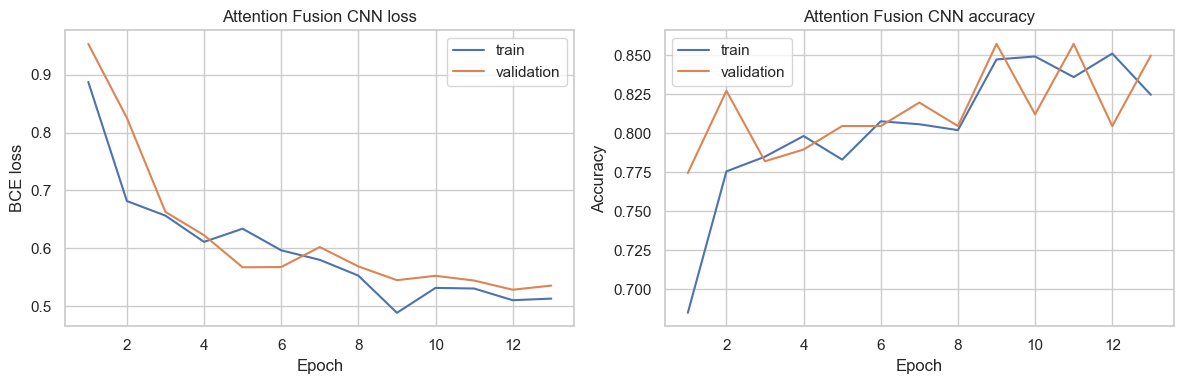

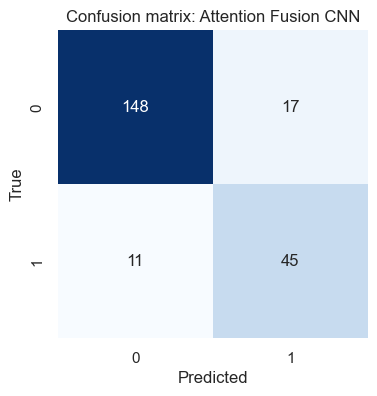

In [12]:
finalist_candidate_ids = (
    search_df.sort_values(["model_group", "val_f1", "val_loss"], ascending=[True, False, True])
    .groupby("model_group", as_index=False)
    .first()["candidate_id"]
    .tolist()
)

finalist_rows = []
finalist_test_metrics = {}
test_criterion = build_weighted_criterion(train_labels, DEVICE)

for candidate_id in finalist_candidate_ids:
    candidate_row = search_df[search_df["candidate_id"] == candidate_id].iloc[0]
    test_metrics = evaluate_model(trained_candidates[candidate_id], test_loader, test_criterion, DEVICE)
    finalist_test_metrics[candidate_id] = test_metrics
    finalist_rows.append(
        {
            **candidate_row.to_dict(),
            "test_loss": test_metrics["loss"],
            "test_accuracy": test_metrics["accuracy"],
            "test_precision": test_metrics["precision"],
            "test_recall": test_metrics["recall"],
            "test_f1": test_metrics["f1"],
        }
    )

finalist_df = pd.DataFrame(finalist_rows).sort_values(
    ["val_f1", "test_f1", "test_loss"],
    ascending=[False, False, True],
).reset_index(drop=True)
display(finalist_df)

best_candidate_id = finalist_df.iloc[0]["candidate_id"]
best_model_name = finalist_df.iloc[0]["model_group"]
best_model = trained_candidates[best_candidate_id]
best_history = candidate_histories[best_candidate_id]
best_metrics = finalist_test_metrics[best_candidate_id]

print(f"Best model by validation F1: {best_model_name}")
print(f"Chosen candidate: {best_candidate_id}")

plot_history(best_history, best_model_name)
plot_confusion(best_metrics["labels"], best_metrics["probabilities"], f"Confusion matrix: {best_model_name}")


In [13]:
class GradCAM1D:
    # Register hooks needed to compute 1D Grad-CAM on a target layer.
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.forward_hook = target_layer.register_forward_hook(self._save_activations)
        self.backward_hook = target_layer.register_full_backward_hook(self._save_gradients)

    # Cache forward activations from the target layer for Grad-CAM.
    def _save_activations(self, module, inputs, output):
        self.activations = output.detach()

    # Cache backward gradients from the target layer for Grad-CAM.
    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    # Remove Grad-CAM hooks once explanations are finished.
    def remove(self):
        self.forward_hook.remove()
        self.backward_hook.remove()

    # Generate a normalized 1D Grad-CAM importance curve for one sample.
    def __call__(self, batch, input_length):
        self.model.eval()
        self.model.zero_grad()
        logits = self.model(batch)
        score = logits[0]
        score.backward(retain_graph=True)

        activations = self.activations[0]
        gradients = self.gradients[0]

        weights = gradients.mean(dim=1, keepdim=True)
        cam = torch.relu((weights * activations).sum(dim=0))

        cam = F.interpolate(
            cam.view(1, 1, -1),
            size=input_length,
            mode="linear",
            align_corners=False,
        ).view(-1)

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam.detach().cpu().numpy()

# Return the EEG layer used as the Grad-CAM target.
def get_gradcam_target_layer(model):
    return model.eeg_encoder.last_conv

# Collect sorted test-set predictions and their metadata fields.
def collect_test_predictions(model, loader):
    criterion = build_weighted_criterion(train_labels, DEVICE)
    metrics = evaluate_model(model, loader, criterion, DEVICE)
    frame = pd.DataFrame(
        {
            "dataset_index": metrics["indices"].astype(int),
            "label": metrics["labels"].astype(int),
            "probability": metrics["probabilities"],
        }
    )
    frame["prediction"] = (frame["probability"] >= 0.5).astype(int)
    return frame.sort_values("probability", ascending=False).reset_index(drop=True)

# Choose a representative test index for explanation plots.
def choose_xai_index(prediction_df):
    positive_hits = prediction_df[(prediction_df["label"] == 1) & (prediction_df["prediction"] == 1)]
    if not positive_hits.empty:
        return int(positive_hits.iloc[0]["dataset_index"])
    positive_windows = prediction_df[prediction_df["label"] == 1]
    if not positive_windows.empty:
        return int(positive_windows.iloc[0]["dataset_index"])
    return int(prediction_df.iloc[0]["dataset_index"])

# Prepare one dataset sample as a batch of size one on the active device.
def get_single_sample(dataset, index):
    batch, label, _ = dataset[index]
    batch = {name: tensor.unsqueeze(0).to(DEVICE) for name, tensor in batch.items()}
    return batch, float(label.item())

# Estimate EEG channel importance from input gradients.
def compute_eeg_channel_importance(model, batch):
    model.eval()
    eeg = batch["eeg"].clone().detach().requires_grad_(True)
    forward_batch = {name: tensor.clone().detach() for name, tensor in batch.items()}
    forward_batch["eeg"] = eeg
    logits = model(forward_batch)
    logits[0].backward()
    importance = eeg.grad.detach().abs().mean(dim=-1).squeeze(0).cpu().numpy()
    return importance

# Extract modality attention weights when the model supports them.
def compute_attention_weights(model, batch):
    if not hasattr(model, "attention"):
        return None
    model.eval()
    with torch.no_grad():
        outputs = model(batch, return_attention=True)
    logits, weights = outputs[0], outputs[1]
    return weights.squeeze(0).cpu().numpy()

# Compute integrated-gradients attributions for the EEG input.
def compute_integrated_gradients_eeg(model, batch, steps=INTEGRATED_GRADIENT_STEPS):
    model.eval()
    baseline = torch.zeros_like(batch["eeg"])
    total_grads = torch.zeros_like(batch["eeg"])
    alphas = torch.linspace(0.0, 1.0, steps + 1, device=DEVICE)[1:]

    for alpha in alphas:
        interpolated = (baseline + alpha * (batch["eeg"] - baseline)).clone().detach().requires_grad_(True)
        forward_batch = {name: tensor.clone().detach() for name, tensor in batch.items()}
        forward_batch["eeg"] = interpolated
        model.zero_grad()
        logits = model(forward_batch)
        logits[0].backward()
        total_grads += interpolated.grad.detach()

    avg_grads = total_grads / len(alphas)
    attributions = (batch["eeg"] - baseline) * avg_grads
    return attributions.detach().cpu().numpy().squeeze(0)

# Measure how much prediction confidence drops when each modality is ablated.
def compute_modality_occlusion_effects(model, batch):
    model.eval()
    with torch.no_grad():
        base_probability = torch.sigmoid(model(batch))[0].item()
        drops = OrderedDict()
        for modality in ["eeg", "ecg", "emg", "mov"]:
            ablated_batch = {name: tensor.clone() for name, tensor in batch.items()}
            ablated_batch[modality] = torch.zeros_like(ablated_batch[modality])
            ablated_probability = torch.sigmoid(model(ablated_batch))[0].item()
            drops[modality.upper()] = base_probability - ablated_probability
    return base_probability, drops

# Find the time segment with the strongest average Grad-CAM score.
def most_important_time_segment(cam_values, sfreq=256.0, segment_sec=2.0):
    segment_samples = max(1, int(round(sfreq * segment_sec)))
    rolling_score = pd.Series(cam_values).rolling(segment_samples, min_periods=1).mean().to_numpy()
    best_end = int(np.nanargmax(rolling_score))
    best_start = max(0, best_end - segment_samples + 1)
    return best_start / sfreq, min(len(cam_values) - 1, best_end) / sfreq

# Plot the learned attention weight assigned to each modality.
def plot_attention(weights, title="Modality attention"):
    modality_names = ["EEG", "ECG", "EMG", "MOV"]
    plt.figure(figsize=(6, 4))
    sns.barplot(x=modality_names, y=weights, hue=modality_names, palette="viridis", legend=False)
    plt.ylim(0, 1)
    plt.title(title)
    plt.ylabel("Attention weight")
    plt.show()

# Plot channel-level importance scores for the EEG explanation.
def plot_channel_importance(values, channel_names, title):
    plt.figure(figsize=(6, 4))
    sns.barplot(x=channel_names, y=values, hue=channel_names, palette="mako", legend=False)
    plt.title(title)
    plt.ylabel("Importance")
    plt.xticks(rotation=15)
    plt.show()

# Plot the EEG window alongside its Grad-CAM time-importance curve.
def plot_gradcam(eeg_signal, cam_values, channel_names, dominant_channel):
    time_axis = np.linspace(0, WINDOW_SEC, eeg_signal.shape[-1], endpoint=False)
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    for index, channel_name in enumerate(channel_names):
        axes[0].plot(time_axis, eeg_signal[index], label=channel_name)
    axes[0].set_title("Normalized EEG window")
    axes[0].set_ylabel("Amplitude")
    axes[0].legend(loc="upper right")

    axes[1].plot(time_axis, cam_values, color="crimson", linewidth=2)
    axes[1].fill_between(time_axis, 0, cam_values, color="crimson", alpha=0.25)
    axes[1].set_title(f"Grad-CAM time importance | dominant channel: {dominant_channel}")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Importance")
    plt.tight_layout()
    plt.show()

# Plot absolute integrated-gradients attributions as an EEG heatmap.
def plot_integrated_gradients(integrated_gradients, channel_names):
    plt.figure(figsize=(12, 4))
    sns.heatmap(np.abs(integrated_gradients), cmap="rocket", cbar=True, yticklabels=channel_names)
    plt.title("Integrated Gradients | absolute EEG attribution")
    plt.xlabel("Time samples")
    plt.ylabel("EEG channel")
    plt.tight_layout()
    plt.show()

# Plot the probability drop caused by occluding each modality.
def plot_modality_occlusion(drops):
    names = list(drops.keys())
    values = list(drops.values())
    plt.figure(figsize=(6, 4))
    sns.barplot(x=names, y=values, hue=names, palette="crest", legend=False)
    plt.title("Modality ablation | probability drop when a modality is zeroed")
    plt.ylabel("Drop in predicted seizure probability")
    plt.show()


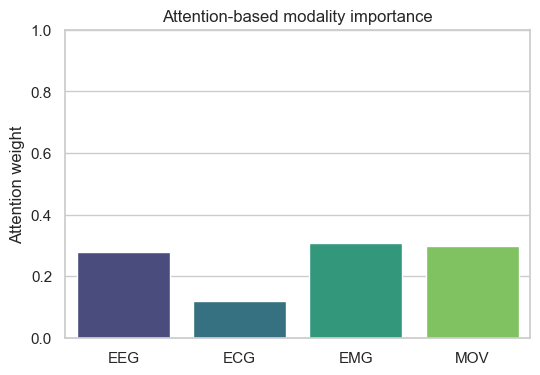

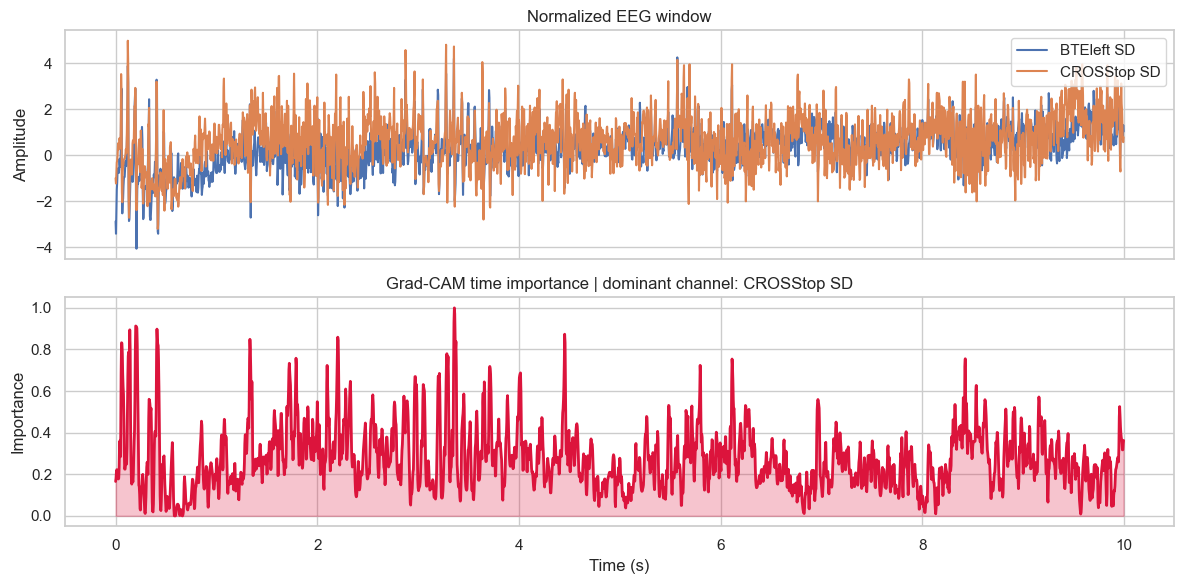

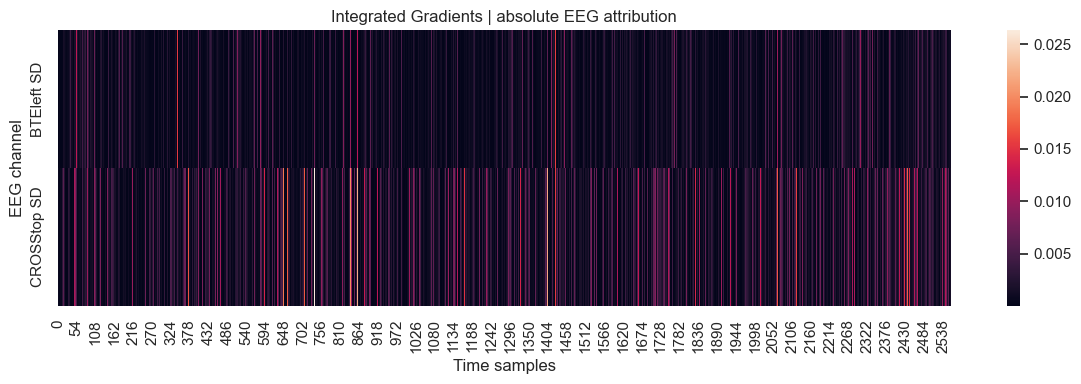

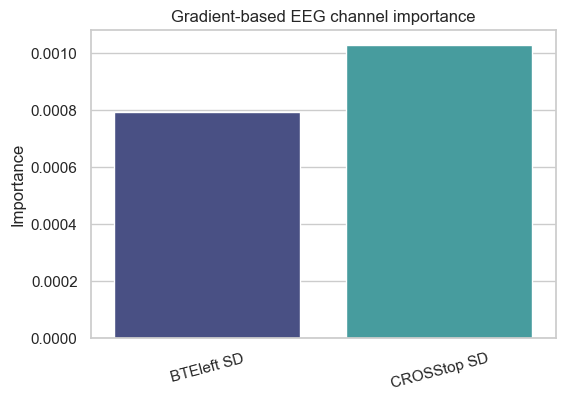

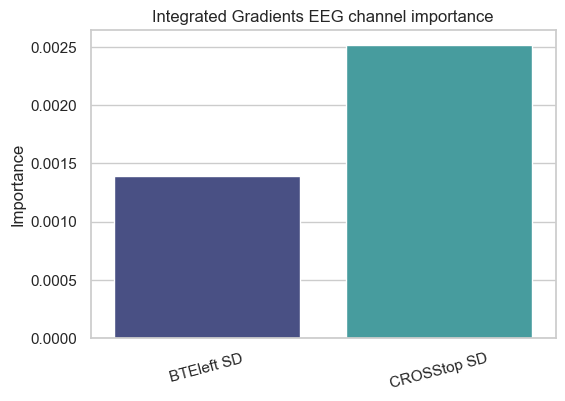

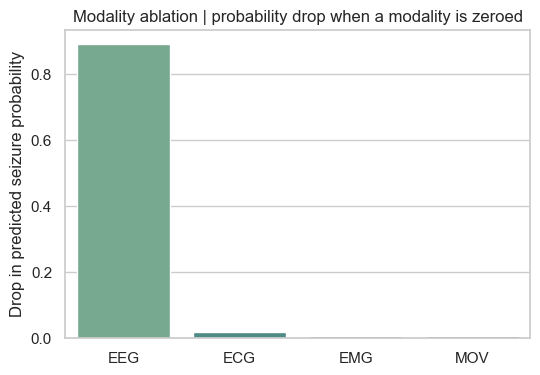

{'dataset_index': 214,
 'true_label': 1,
 'predicted_probability': 0.9878610968589783,
 'dominant_modality': 'EMG',
 'attention_weights': array([0.27763367, 0.11924934, 0.30618906, 0.29692796], dtype=float32),
 'dominant_attention_modality': 'EMG',
 'dominant_occlusion_modality': 'EEG',
 'modality_occlusion_drop': OrderedDict([('EEG', 0.890107125043869),
              ('ECG', 0.018016278743743896),
              ('EMG', 0.005909621715545654),
              ('MOV', 0.0048618316650390625)]),
 'dominant_eeg_channel': 'CROSStop SD',
 'channel_importance': array([0.00079314, 0.00103004], dtype=float32),
 'integrated_gradients': array([[ 0.00142236,  0.00496824, -0.00014643, ..., -0.00273338,
          0.00064145,  0.00107694],
        [ 0.00089571,  0.00375411,  0.00071006, ..., -0.00011917,
         -0.00013293, -0.00149778]], shape=(2, 2560), dtype=float32),
 'ig_channel_importance': array([0.00139476, 0.00251817], dtype=float32),
 'ig_dominant_eeg_channel': 'CROSStop SD',
 'important_tim

In [14]:
prediction_df = collect_test_predictions(best_model, test_loader)
xai_index = choose_xai_index(prediction_df)
xai_batch, xai_label = get_single_sample(test_dataset, xai_index)
xai_meta = test_meta.iloc[xai_index]

best_model.eval()
with torch.no_grad():
    xai_logit = best_model(xai_batch)
    xai_probability = torch.sigmoid(xai_logit)[0].item()

gradcam = GradCAM1D(best_model, get_gradcam_target_layer(best_model))
cam_values = gradcam(xai_batch, input_length=xai_batch["eeg"].shape[-1])
gradcam.remove()

channel_importance = compute_eeg_channel_importance(best_model, xai_batch)
dominant_channel_index = int(np.argmax(channel_importance))
eeg_channel_names = list(xai_meta["eeg_channels"])
dominant_channel_name = eeg_channel_names[dominant_channel_index]

integrated_gradients = compute_integrated_gradients_eeg(best_model, xai_batch, steps=INTEGRATED_GRADIENT_STEPS)
ig_channel_importance = np.abs(integrated_gradients).mean(axis=1)
ig_dominant_channel_name = eeg_channel_names[int(np.argmax(ig_channel_importance))]

eeg_sfreq = read_json(runs_df.iloc[0]["eeg_json"])["SamplingFrequency"]
important_start_sec, important_end_sec = most_important_time_segment(cam_values, sfreq=eeg_sfreq, segment_sec=2.0)

attention_weights = compute_attention_weights(best_model, xai_batch)
if attention_weights is not None:
    dominant_attention_modality = ["EEG", "ECG", "EMG", "MOV"][int(np.argmax(attention_weights))]
    plot_attention(attention_weights, title="Attention-based modality importance")
else:
    dominant_attention_modality = None

base_probability, modality_occlusion_drop = compute_modality_occlusion_effects(best_model, xai_batch)
dominant_occlusion_modality = max(modality_occlusion_drop, key=modality_occlusion_drop.get)

plot_gradcam(
    xai_batch["eeg"].detach().cpu().numpy().squeeze(0),
    cam_values,
    eeg_channel_names,
    dominant_channel_name,
)
plot_integrated_gradients(integrated_gradients, eeg_channel_names)
plot_channel_importance(channel_importance, eeg_channel_names, "Gradient-based EEG channel importance")
plot_channel_importance(ig_channel_importance, eeg_channel_names, "Integrated Gradients EEG channel importance")
plot_modality_occlusion(modality_occlusion_drop)

xai_summary = {
    "dataset_index": xai_index,
    "true_label": int(xai_label),
    "predicted_probability": xai_probability,
    "dominant_modality": dominant_attention_modality or dominant_occlusion_modality,
    "attention_weights": attention_weights,
    "dominant_attention_modality": dominant_attention_modality,
    "dominant_occlusion_modality": dominant_occlusion_modality,
    "modality_occlusion_drop": modality_occlusion_drop,
    "dominant_eeg_channel": dominant_channel_name,
    "channel_importance": channel_importance,
    "integrated_gradients": integrated_gradients,
    "ig_channel_importance": ig_channel_importance,
    "ig_dominant_eeg_channel": ig_dominant_channel_name,
    "important_time_segment_sec": (important_start_sec, important_end_sec),
    "baseline_probability": base_probability,
}
xai_summary


In [15]:
# Round voxel coordinates to readable millimeter values.
def format_coord_mm(coord):
    return tuple(round(float(value), 2) for value in coord)


# Infer left, right, or midline laterality from the x coordinate.
def infer_hemisphere(x_coord):
    if x_coord < -5:
        return "left"
    if x_coord > 5:
        return "right"
    return "midline"


# Rank the strongest voxels in an image and summarize their coordinates.
def make_top_voxel_table(img, metric_name, top_k=5):
    data = img.get_fdata(dtype=np.float32)
    flat = data.reshape(-1)
    top_k = min(top_k, flat.size)
    top_indices = np.argpartition(flat, -top_k)[-top_k:]
    top_indices = top_indices[np.argsort(flat[top_indices])[::-1]]

    rows = []
    for rank, flat_index in enumerate(top_indices, start=1):
        voxel_index = tuple(int(i) for i in np.unravel_index(int(flat_index), data.shape))
        coord_mm = nib.affines.apply_affine(img.affine, voxel_index)
        rows.append(
            {
                "rank": rank,
                "metric": metric_name,
                "value": float(flat[int(flat_index)]),
                "voxel_index": voxel_index,
                "coord_mm": format_coord_mm(coord_mm),
                "hemisphere": infer_hemisphere(coord_mm[0]),
            }
        )
    return pd.DataFrame(rows)


# Build descriptive fMRI summary statistics, hotspot maps, and voxel tables.
def extract_fmri_summary(fmri_path: Path, run_aal=False, top_k=5):
    img = image.load_img(str(fmri_path))
    data = img.get_fdata(dtype=np.float32)
    mean_img = image.mean_img(img)
    mean_data = mean_img.get_fdata(dtype=np.float32)

    if data.ndim == 4:
        std_data = np.nanstd(data, axis=-1).astype(np.float32)
        temporal_profile = np.nanmean(data, axis=(0, 1, 2)).astype(np.float32)
    else:
        std_data = np.zeros_like(mean_data, dtype=np.float32)
        temporal_profile = np.array([float(np.nanmean(data))], dtype=np.float32)

    std_img = image.new_img_like(mean_img, std_data)

    peak_mean_voxel = tuple(int(i) for i in np.unravel_index(int(np.nanargmax(mean_data)), mean_data.shape))
    peak_std_voxel = tuple(int(i) for i in np.unravel_index(int(np.nanargmax(std_data)), std_data.shape))
    peak_mean_coord = nib.affines.apply_affine(mean_img.affine, peak_mean_voxel)
    peak_std_coord = nib.affines.apply_affine(std_img.affine, peak_std_voxel)

    mean_hotspot_threshold = float(np.nanpercentile(mean_data, 99.5))
    std_hotspot_threshold = float(np.nanpercentile(std_data, 99.5))
    mean_hotspot_data = np.where(mean_data >= mean_hotspot_threshold, mean_data, 0.0).astype(np.float32)
    std_hotspot_data = np.where(std_data >= std_hotspot_threshold, std_data, 0.0).astype(np.float32)

    summary = {
        "shape": img.shape,
        "mean_activation": float(np.nanmean(data)),
        "variance_activation": float(np.nanvar(data)),
        "min_activation": float(np.nanmin(data)),
        "max_activation": float(np.nanmax(data)),
        "n_timepoints": int(img.shape[-1]) if len(img.shape) == 4 else 1,
        "mean_image": mean_img,
        "std_image": std_img,
        "mean_hotspot_image": image.new_img_like(mean_img, mean_hotspot_data),
        "std_hotspot_image": image.new_img_like(std_img, std_hotspot_data),
        "temporal_profile": temporal_profile,
        "peak_mean_voxel": peak_mean_voxel,
        "peak_mean_coord_mm": format_coord_mm(peak_mean_coord),
        "peak_mean_hemisphere": infer_hemisphere(peak_mean_coord[0]),
        "peak_std_voxel": peak_std_voxel,
        "peak_std_coord_mm": format_coord_mm(peak_std_coord),
        "peak_std_hemisphere": infer_hemisphere(peak_std_coord[0]),
        "mean_hotspot_threshold": mean_hotspot_threshold,
        "mean_hotspot_fraction": float(np.mean(mean_data >= mean_hotspot_threshold)),
        "std_hotspot_threshold": std_hotspot_threshold,
        "std_hotspot_fraction": float(np.mean(std_data >= std_hotspot_threshold)),
        "mean_top_voxels": make_top_voxel_table(mean_img, "mean_activation", top_k=top_k),
        "std_top_voxels": make_top_voxel_table(std_img, "temporal_std", top_k=top_k),
        "aal_regions": None,
    }

    if run_aal:
        try:
            from nilearn import datasets

            atlas = datasets.fetch_atlas_aal()
            atlas_img = image.load_img(atlas.maps)
            atlas_data = atlas_img.get_fdata().astype(int)
            region_rows = []
            for atlas_index, label in zip(atlas.indices, atlas.labels):
                atlas_index = int(atlas_index)
                mask = atlas_data == atlas_index
                if np.any(mask):
                    region_rows.append(
                        {
                            "region": label,
                            "mean_activation": float(mean_data[mask].mean()),
                        }
                    )
            if region_rows:
                summary["aal_regions"] = pd.DataFrame(region_rows).sort_values(
                    "mean_activation", ascending=False
                )
        except Exception as exc:
            print(f"AAL atlas step skipped: {exc}")

    return summary


# Visualize the fMRI summary with distributions, time course, and hotspot maps.
def plot_fmri_xai(summary):
    mean_data = summary["mean_image"].get_fdata(dtype=np.float32)
    temporal_profile = summary["temporal_profile"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(mean_data.ravel(), bins=60, color="#4c72b0", alpha=0.85)
    axes[0].axvline(summary["mean_hotspot_threshold"], color="crimson", linestyle="--", linewidth=2)
    axes[0].set_title("Mean-image voxel distribution")
    axes[0].set_xlabel("Mean voxel activation")
    axes[0].set_ylabel("Voxel count")

    axes[1].plot(np.arange(len(temporal_profile)), temporal_profile, color="#dd8452", linewidth=2)
    axes[1].set_title("Global mean signal across fMRI volumes")
    axes[1].set_xlabel("Volume index")
    axes[1].set_ylabel("Mean activation")

    plt.tight_layout()
    plt.show()

    plotting.plot_stat_map(
        summary["mean_hotspot_image"],
        title="fMRI mean-activation hotspot (top 0.5% voxels)",
        display_mode="ortho",
        cut_coords=summary["peak_mean_coord_mm"],
        colorbar=True,
    )
    plt.show()

    plotting.plot_stat_map(
        summary["std_hotspot_image"],
        title="fMRI temporal-variability hotspot (top 0.5% voxels)",
        display_mode="ortho",
        cut_coords=summary["peak_std_coord_mm"],
        colorbar=True,
    )
    plt.show()


,feature,value
0,shape,"(91, 109, 91, 265)"
1,timepoints,265
2,mean_activation,211.791824
3,variance,136000.875
4,min,-76.61142
5,max,1615.665283
6,peak_mean_coord_mm,"(-4.0, 56.0, -4.0)"
7,peak_mean_hemisphere,midline
8,peak_std_coord_mm,"(0.0, -14.0, -50.0)"
9,peak_std_hemisphere,midline


Top mean-activation voxels:


,rank,metric,value,voxel_index,coord_mm,hemisphere
0,1,mean_activation,1594.857788,"(47, 91, 34)","(-4.0, 56.0, -4.0)",midline
1,2,mean_activation,1592.891724,"(47, 91, 33)","(-4.0, 56.0, -6.0)",midline
2,3,mean_activation,1565.350220,"(45, 64, 27)","(0.0, 2.0, -18.0)",midline
3,4,mean_activation,1541.134521,"(45, 64, 28)","(0.0, 2.0, -16.0)",midline
4,5,mean_activation,1525.716919,"(44, 64, 27)","(2.0, 2.0, -18.0)",midline


Top temporal-variability voxels:


,rank,metric,value,voxel_index,coord_mm,hemisphere
0,1,temporal_std,44.046661,"(45, 56, 11)","(0.0, -14.0, -50.0)",midline
1,2,temporal_std,41.481239,"(45, 56, 10)","(0.0, -14.0, -52.0)",midline
2,3,temporal_std,41.325089,"(47, 57, 13)","(-4.0, -12.0, -46.0)",midline
3,4,temporal_std,38.238487,"(33, 59, 12)","(24.0, -8.0, -48.0)",right
4,5,temporal_std,38.115669,"(48, 61, 23)","(-6.0, -4.0, -26.0)",left


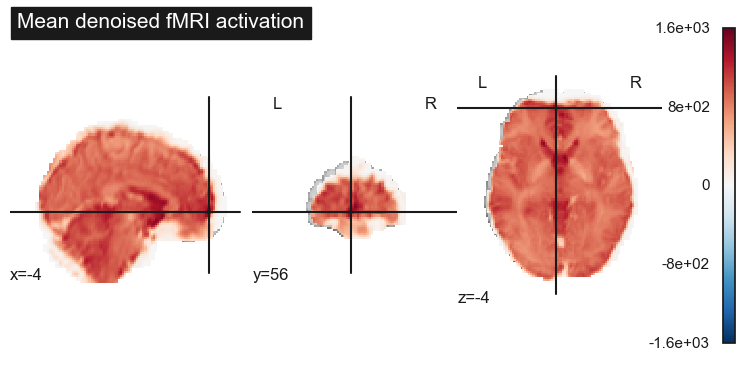

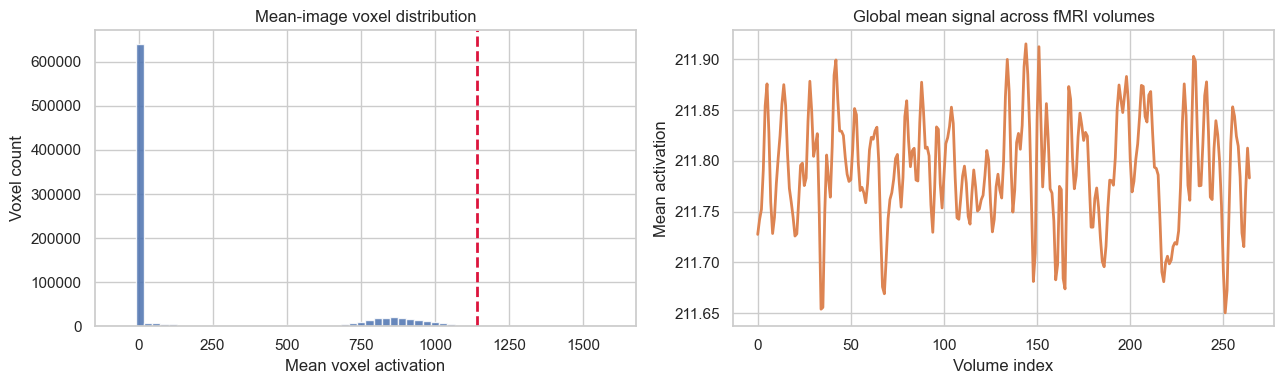

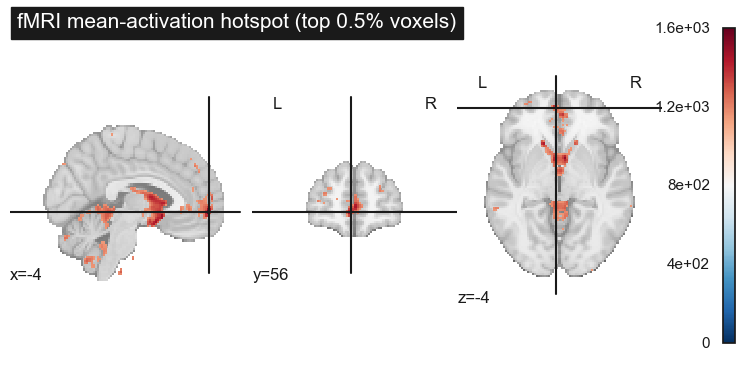

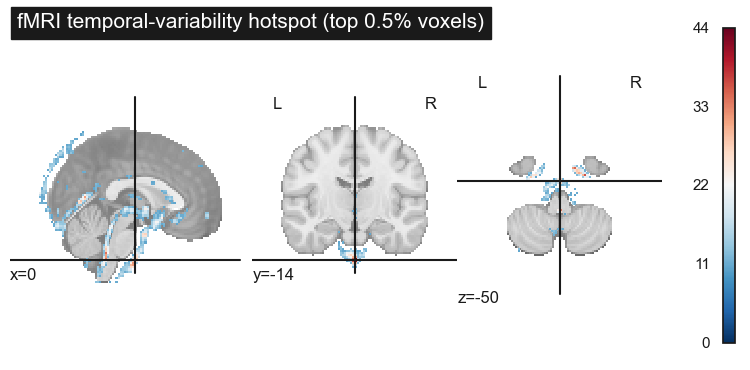

In [16]:
fmri_summary = extract_fmri_summary(FMRI_PATH, run_aal=False)

temporal_profile = fmri_summary["temporal_profile"]
fmri_table = pd.DataFrame(
    {
        "feature": [
            "shape",
            "timepoints",
            "mean_activation",
            "variance",
            "min",
            "max",
            "peak_mean_coord_mm",
            "peak_mean_hemisphere",
            "peak_std_coord_mm",
            "peak_std_hemisphere",
            "mean_hotspot_threshold",
            "mean_hotspot_fraction",
            "std_hotspot_threshold",
            "std_hotspot_fraction",
            "temporal_profile_range",
        ],
        "value": [
            str(fmri_summary["shape"]),
            fmri_summary["n_timepoints"],
            fmri_summary["mean_activation"],
            fmri_summary["variance_activation"],
            fmri_summary["min_activation"],
            fmri_summary["max_activation"],
            fmri_summary["peak_mean_coord_mm"],
            fmri_summary["peak_mean_hemisphere"],
            fmri_summary["peak_std_coord_mm"],
            fmri_summary["peak_std_hemisphere"],
            fmri_summary["mean_hotspot_threshold"],
            fmri_summary["mean_hotspot_fraction"],
            fmri_summary["std_hotspot_threshold"],
            fmri_summary["std_hotspot_fraction"],
            f"{float(np.min(temporal_profile)):.4f} to {float(np.max(temporal_profile)):.4f}",
        ],
    }
)
display(fmri_table)

print("Top mean-activation voxels:")
display(fmri_summary["mean_top_voxels"])

print("Top temporal-variability voxels:")
display(fmri_summary["std_top_voxels"])

plotting.plot_stat_map(
    fmri_summary["mean_image"],
    title="Mean denoised fMRI activation",
    display_mode="ortho",
    cut_coords=fmri_summary["peak_mean_coord_mm"],
    colorbar=True,
)
plt.show()

plot_fmri_xai(fmri_summary)


In [17]:
EEG_REGION_MAP = {
    "BTEleft SD": "left temporal / mastoid region",
    "BTEright SD": "right temporal / mastoid region",
    "CROSStop SD": "cross-head temporo-parietal trajectory",
}


# Describe whether seizure laterality agrees with the fMRI hotspot side.
def describe_fmri_laterality(lateralization, peak_hemisphere):
    lateralization = str(lateralization).lower()
    if "left" in lateralization and peak_hemisphere == "left":
        return "The seizure annotation and the fMRI hotspot are both left-lateralized, which is directionally aligned."
    if "right" in lateralization and peak_hemisphere == "right":
        return "The seizure annotation and the fMRI hotspot are both right-lateralized, which is directionally aligned."
    if lateralization in {"n/a", "nan", "none"} or peak_hemisphere == "midline":
        return "The fMRI hotspot does not provide a strong laterality cue, so the cross-modal comparison stays qualitative."
    return "The seizure annotation and the fMRI hotspot do not clearly share the same lateralization, so agreement is limited."


# Assemble the final plain-language multimodal interpretation summary.
def build_interpretation_text(best_model_name, xai_summary, xai_meta, fmri_summary):
    predicted_label = "seizure" if xai_summary["predicted_probability"] >= 0.5 else "background"
    eeg_channel = xai_summary["dominant_eeg_channel"]
    eeg_region = EEG_REGION_MAP.get(eeg_channel, "approximate peri-auricular region")
    time_start, time_end = xai_summary["important_time_segment_sec"]
    temporal_profile = fmri_summary["temporal_profile"]

    lines = [
        f"Best model: {best_model_name}.",
        f"Selected test window prediction: {predicted_label} (probability={xai_summary['predicted_probability']:.3f}).",
        f"Window source: {xai_meta['source']} | event label: {xai_meta['event_type']} | localization: {xai_meta['localization']} | lateralization: {xai_meta['lateralization']}.",
        f"Most important EEG channel by input gradients: {eeg_channel}, mapped to the {eeg_region}.",
        f"Integrated Gradients also ranked {xai_summary['ig_dominant_eeg_channel']} as the strongest EEG channel.",
        f"Most important EEG time segment inside the 10-second window: {time_start:.2f}s to {time_end:.2f}s.",
    ]

    if xai_summary["attention_weights"] is not None:
        lines.append(f"Most important modality by attention: {xai_summary['dominant_attention_modality']}.")

    lines.append(
        f"Largest probability drop under modality ablation came from removing {xai_summary['dominant_occlusion_modality']}."
    )

    lines.append(
        "Post-hoc fMRI summary from the denoised derivative shows "
        f"mean activation {fmri_summary['mean_activation']:.4f} and variance {fmri_summary['variance_activation']:.4f}."
    )

    lines.append(
        "The strongest mean-activation fMRI hotspot appears near "
        f"{fmri_summary['peak_mean_coord_mm']} mm in the {fmri_summary['peak_mean_hemisphere']} hemisphere, "
        f"and the top 0.5% of mean-activation voxels cover {100 * fmri_summary['mean_hotspot_fraction']:.2f}% of the volume."
    )

    if fmri_summary["n_timepoints"] > 1:
        lines.append(
            "The strongest temporal-variability hotspot appears near "
            f"{fmri_summary['peak_std_coord_mm']} mm in the {fmri_summary['peak_std_hemisphere']} hemisphere, "
            f"while the global mean fMRI signal ranges from {float(np.min(temporal_profile)):.4f} to {float(np.max(temporal_profile)):.4f} across {fmri_summary['n_timepoints']} volumes."
        )

    if str(xai_meta["localization"]).startswith("temp") and "temporal" in eeg_region:
        lines.append(
            "The seizure annotation and the wearable EEG attribution both point toward temporal territory, which is directionally consistent."
        )
    else:
        lines.append(
            "The wearable EEG attribution and the seizure annotation can be compared qualitatively, but this remains a coarse spatial interpretation."
        )

    lines.append(describe_fmri_laterality(xai_meta["lateralization"], fmri_summary["peak_mean_hemisphere"]))
    lines.append(
        "The fMRI file belongs to a different dataset and subject than the wearable seizure data, so this agreement should be treated as illustrative rather than subject-level confirmation."
    )
    return "\n".join(lines)


final_interpretation = build_interpretation_text(best_model_name, xai_summary, xai_meta, fmri_summary)
print(final_interpretation)


Best model: Attention Fusion CNN.
Selected test window prediction: seizure (probability=0.988).
Window source: seizure_context | event label: sz_foc_ia_m_hyperkinetic | localization: cen_par | lateralization: right.
Most important EEG channel by input gradients: CROSStop SD, mapped to the cross-head temporo-parietal trajectory.
Integrated Gradients also ranked CROSStop SD as the strongest EEG channel.
Most important EEG time segment inside the 10-second window: 0.00s to 0.22s.
Most important modality by attention: EMG.
Largest probability drop under modality ablation came from removing EEG.
Post-hoc fMRI summary from the denoised derivative shows mean activation 211.7918 and variance 136000.8750.
The strongest mean-activation fMRI hotspot appears near (-4.0, 56.0, -4.0) mm in the midline hemisphere, and the top 0.5% of mean-activation voxels cover 0.50% of the volume.
The strongest temporal-variability hotspot appears near (0.0, -14.0, -50.0) mm in the midline hemisphere, while the glo